In [1]:
from astropy.table import Table, vstack
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import scienceplots
import fitsio
from scipy.stats import norm

plt.style.use(['science', 'notebook', 'grid'])

/user/animesh.sah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
table= Table(fitsio.read('north_merged_test.fits'))

In [3]:
np.count_nonzero(table['FLUX_Z']<=0) ,np.count_nonzero(table['FLUX_G']<=0) ,np.count_nonzero(table['FLUX_R']<=0)

(1465825, 1506969, 1386629)

(array([ 237.,    0., 1333.,    0., 3414.,    0., 3447.,    0., 1340.,
         229.]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]),
 <BarContainer object of 10 artists>)

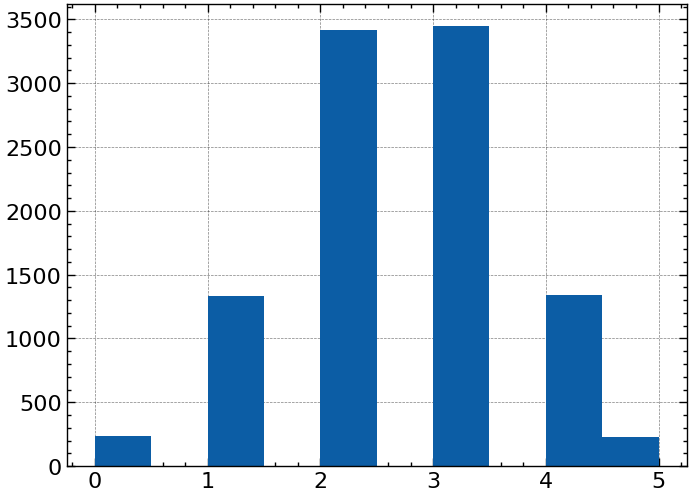

In [4]:
a = np.random.normal(0,1,10000)
x = np.digitize(a,bins = [-2,-1,0,1,2])
plt.hist(x)

In [5]:
z_mask = (table['FLUX_Z'] > 0) & (table['FLUX_IVAR_Z'] > 0)
g_mask = (table['FLUX_G'] > 0) & (table['FLUX_IVAR_G'] > 0)
r_mask = (table['FLUX_R'] > 0) & (table['FLUX_IVAR_R'] > 0)
np.count_nonzero(z_mask) , np.count_nonzero(g_mask) ,np.count_nonzero(r_mask)

(4783744, 4741358, 4861413)

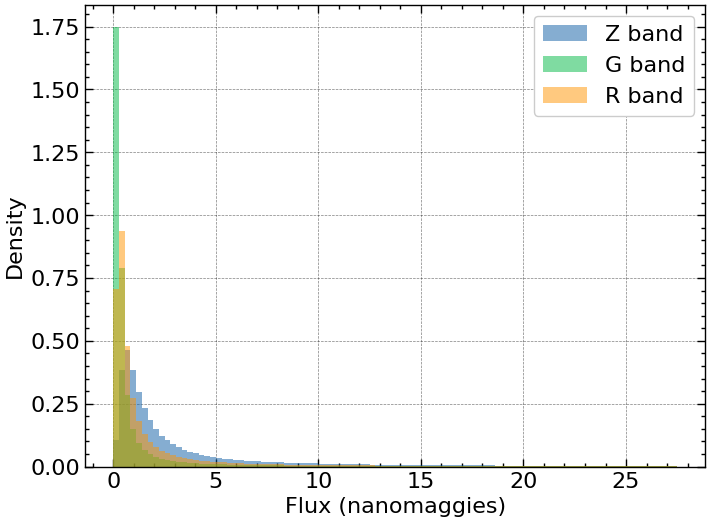

In [6]:
bins = np.linspace(0, np.percentile(table['FLUX_Z'][z_mask], 90), 100)
plt.hist(table['FLUX_Z'][z_mask], bins=bins, alpha=0.5, label='Z band', density=True)
plt.hist(table['FLUX_G'][g_mask], bins=bins, alpha=0.5, label='G band', density=True)
plt.hist(table['FLUX_R'][r_mask], bins=bins,  alpha=0.5, label='R band', density=True)
#plt.yscale('log')
plt.xlabel('Flux (nanomaggies)')
plt.ylabel('Density')
plt.legend()    

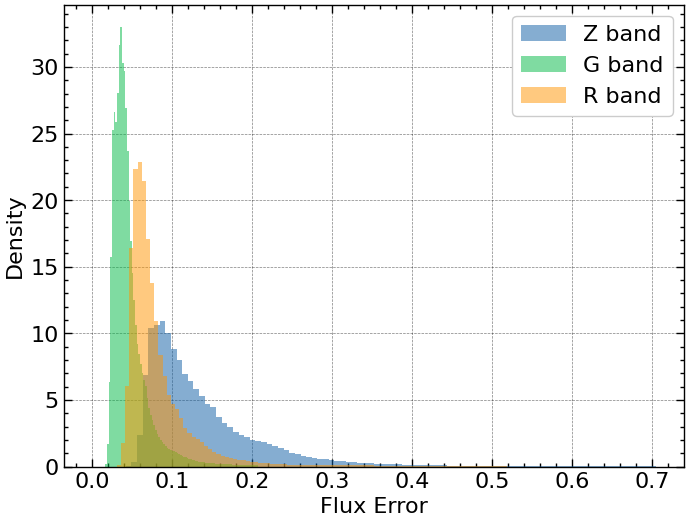

In [7]:
plt.hist(np.sqrt(1/table['FLUX_IVAR_Z'][z_mask]),bins = 100, range=(0,np.percentile(np.sqrt(1/table['FLUX_IVAR_Z'][z_mask]),98)), alpha=0.5, label='Z band', density=True)
plt.hist(np.sqrt(1/table['FLUX_IVAR_G'][g_mask]),bins = 100, range=(0,np.percentile(np.sqrt(1/table['FLUX_IVAR_G'][g_mask]),98)), alpha=0.5, label='G band', density=True)
plt.hist(np.sqrt(1/table['FLUX_IVAR_R'][r_mask]),bins = 100, range=(0,np.percentile(np.sqrt(1/table['FLUX_IVAR_R'][r_mask]),98)), alpha=0.5, label='R band', density=True)
plt.xlabel('Flux Error')
plt.ylabel('Density')
plt.legend()
plt.show()

(-1.0, 1694.5978594970716)

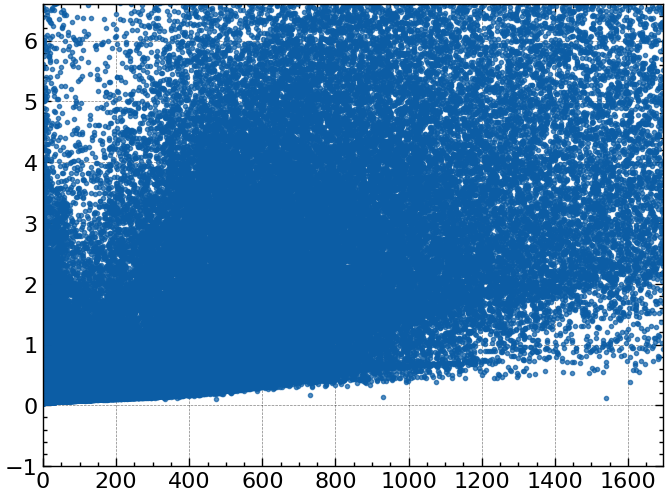

In [8]:
plt.plot(table['FLUX_Z'][z_mask], 1/np.sqrt(table['FLUX_IVAR_Z'][z_mask]), '.', alpha=0.7)
plt.ylim(-1,np.percentile(1/np.sqrt(table['FLUX_IVAR_Z'][z_mask]),99.5)+0.1)
plt.xlim(-1,np.percentile(table['FLUX_Z'][z_mask], 99.5)+10)

(-1.0, 2085.2963486327935)

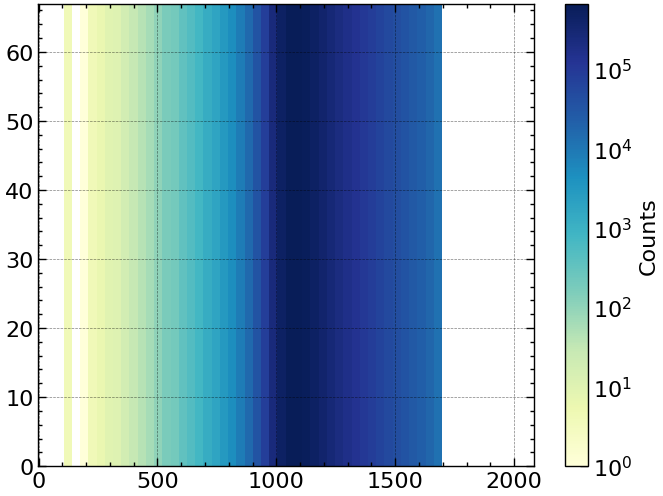

In [9]:
binx = np.logspace(np.log10(min(table['FLUX_Z'][z_mask])), np.log10(np.percentile(table['FLUX_Z'][z_mask], 99.5)+10), 50)
biny = np.linspace(min(1/np.sqrt(table['FLUX_IVAR_Z'][z_mask])), max(1/np.sqrt(table['FLUX_IVAR_Z'][z_mask])), 50)
hist,xedges,yedges=np.histogram2d(table['FLUX_Z'][z_mask], 1/np.sqrt(table['FLUX_IVAR_Z'][z_mask]), bins=(binx, biny))
plt.imshow(hist.T, origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        aspect='auto',cmap='YlGnBu',norm=LogNorm())
plt.colorbar(label='Counts')
#plt.xscale('log')
plt.ylim(0,np.percentile(1/np.sqrt(table['FLUX_IVAR_Z'][z_mask]),99.995)+0.1)
plt.xlim(-1,np.percentile(table['FLUX_Z'][z_mask], 99.6)+10)
#plt.ylim(-0.01,np.percentile(1/np.sqrt(table['FLUX_IVAR_Z'][z_mask]),99.5)+0.1)

In [10]:
def return_flux(flux_raw,ivar_raw):
    flux  = flux_raw
    sigma = 1 / np.sqrt(ivar_raw)

    good = np.isfinite(flux) & np.isfinite(sigma) & (flux > 0) & (sigma > 0)
    flux, sigma = flux[good], sigma[good]
    return flux, sigma

In [11]:
def compute_flux_error_stats(flux, sigma):
    # Define logarithmic bins for flux
    bins = np.logspace(
        np.log10(np.percentile(flux, 0.25)),
        np.log10(np.percentile(flux, 99.75)),
        100
    )
    bin_centers = 0.5 * (bins[1:] + bins[:-1])

    # Digitize flux values into bins
    bin_indices = np.digitize(flux, bins)

    # Vectorized computation of statistics per bin
    sigma_med = np.array([
        np.median(sigma[bin_indices == i]) if np.sum(bin_indices == i) > 20 else np.nan
        for i in range(1, len(bins))
    ])

    sigma_p_lower = np.array([
        np.percentile(sigma[bin_indices == i], 0.3) if np.sum(bin_indices == i) > 20 else np.nan
        for i in range(1, len(bins))
    ])

    sigma_p_upper = np.array([
        np.percentile(sigma[bin_indices == i], 99.7) if np.sum(bin_indices == i) > 20 else np.nan
        for i in range(1, len(bins))
    ])
    return bin_centers, sigma_med, sigma_p_lower, sigma_p_upper

In [12]:
flux,sigma = return_flux(table['FLUX_Z'], table['FLUX_IVAR_Z'])
bin_centers, sigma_med, sigma_p_lower, sigma_p_upper = compute_flux_error_stats(flux, sigma)

/tmp/ipykernel_2203152/4267711751.py:3: RuntimeWarning: divide by zero encountered in divide
  sigma = 1 / np.sqrt(ivar_raw)


/tmp/ipykernel_2203152/4267711751.py:3: RuntimeWarning: divide by zero encountered in divide
  sigma = 1 / np.sqrt(ivar_raw)


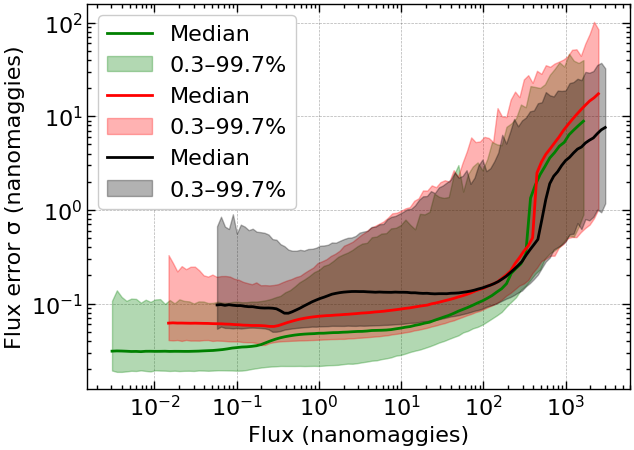

In [13]:
plt.figure(figsize=(7,5))
#plt.scatter(flux, sigma, s=2, alpha=0.05, color='gray')
flux,sigma = return_flux(table['FLUX_G'], table['FLUX_IVAR_G'])
bin_centers, sigma_med, sigma_p_lower, sigma_p_upper = compute_flux_error_stats(flux, sigma)
plt.plot(bin_centers, sigma_med, 'g-', lw=2, label='Median')
plt.fill_between(
    bin_centers, sigma_p_lower, sigma_p_upper,
    color='green', alpha=0.3, label='0.3–99.7%'
)

flux,sigma = return_flux(table['FLUX_R'], table['FLUX_IVAR_R'])
bin_centers, sigma_med, sigma_p_lower, sigma_p_upper = compute_flux_error_stats(flux, sigma)
plt.plot(bin_centers, sigma_med, 'r-', lw=2, label='Median')
plt.fill_between(
    bin_centers, sigma_p_lower, sigma_p_upper,
    color='red', alpha=0.3, label='0.3–99.7%'
)

flux,sigma = return_flux(table['FLUX_Z'], table['FLUX_IVAR_Z'])
bin_centers, sigma_med, sigma_p_lower, sigma_p_upper = compute_flux_error_stats(flux, sigma)
plt.plot(bin_centers, sigma_med, 'k-', lw=2, label='Median')
plt.fill_between(
    bin_centers, sigma_p_lower, sigma_p_upper,
    color='black', alpha=0.3, label='0.3–99.7%'
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Flux (nanomaggies)')
plt.ylabel('Flux error σ (nanomaggies)')
plt.legend()
#plt.plot(bin_centers, sigma_med * np.sqrt(bin_centers), '--')

plt.grid(alpha=0.3)


In [14]:
north_stats = Table.read('../flux_error_stats_north_test.fits')
south_stats = Table.read('../flux_error_stats_south.fits')

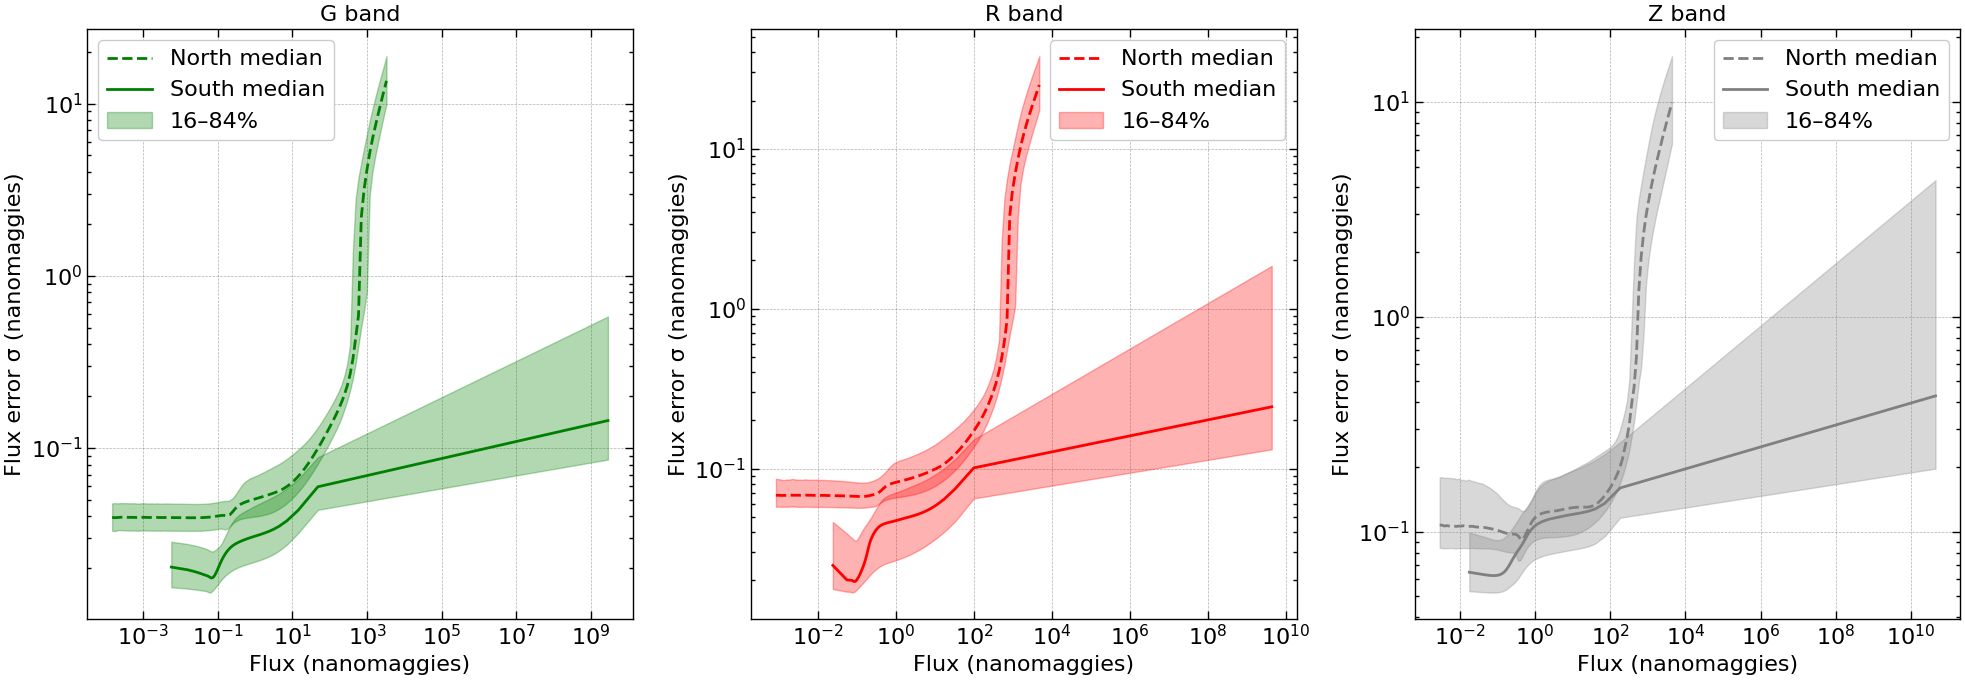

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colors = {'G': 'green', 'R': 'red', 'Z': 'gray'}
for idx, band in enumerate(['G', 'R', 'Z']):
    ax = axes[idx]
    band_stats_north = north_stats[north_stats['band'] == band]
    band_stats_south = south_stats[south_stats['band'] == band]
    
    ax.plot(
        band_stats_north['flux_bin_center'],
        band_stats_north['sigma_median'],
        lw=2,
        label='North median',
        ls='--',
        color=colors[band]
    )
    ax.fill_between(
        band_stats_north['flux_bin_center'],
        band_stats_north['sigma_p16'],
        band_stats_north['sigma_p84'],
        alpha=0.3,
        
        color=colors[band]
    )
    ax.plot(
        band_stats_south['flux_bin_center'],
        band_stats_south['sigma_median'],
        lw=2,
        label='South median',
        ls='-',
        color=colors[band]
    )
    ax.fill_between(
        band_stats_south['flux_bin_center'],
        band_stats_south['sigma_p16'],
        band_stats_south['sigma_p84'],
        alpha=0.3,
        label='16–84%',
        color=colors[band]
    )
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Flux (nanomaggies)')
    ax.set_ylabel('Flux error σ (nanomaggies)')
    ax.set_title(f'{band} band')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()

In [16]:
from joblib import Parallel, delayed

cut = 5
n_iterations = 100000
n_samples_north = 100000
n_samples_south = 200000
sd_north = 0.5
sd_south = 0.4

master_rng = np.random.default_rng(12345)
rngs = master_rng.spawn(n_iterations)

def run_iteration(rng):
    # Generate all random values at once
    x_north_true = rng.uniform(0, 10, n_samples_north)
    x_south_true = rng.uniform(0, 10, n_samples_south)
    x_north_noise = rng.normal(0, sd_north, n_samples_north)
    x_south_noise = rng.normal(0, sd_south, n_samples_south)
    downgrade_noise = rng.normal(0, np.sqrt(sd_north**2 - sd_south**2), n_samples_south)
    
    # Compute measurements
    x_north_measured = x_north_true + x_north_noise
    x_south_measured = x_south_true + x_south_noise
    x_downgraded1 = x_south_measured + downgrade_noise
    
    # Apply cuts and count
    result = np.array([
        np.sum((x_north_measured < cut) & (x_north_true > cut)) / n_samples_north,
        np.sum((x_south_measured < cut) & (x_south_true > cut)) / n_samples_south,
        np.sum((x_downgraded1 < cut) & (x_south_true > cut)) / n_samples_south
    ])
    return result

outliers = np.array(Parallel(n_jobs=-1)(delayed(run_iteration)(rng) for rng in rngs))

In [17]:
x_north_noise = np.random.normal(0, sd_north, n_samples_north)
x_north_true = np.random.uniform(0, 10, n_samples_north)
x_south_noise = np.random.normal(0, sd_south, n_samples_south)
downgrade_noise = np.random.normal(0, np.sqrt(sd_north**2 - sd_south**2), n_samples_south)
x_south_true = np.random.uniform(0, 10, n_samples_south)
x_south_measured = x_south_true + x_south_noise
x_north_measured = x_north_true + x_north_noise

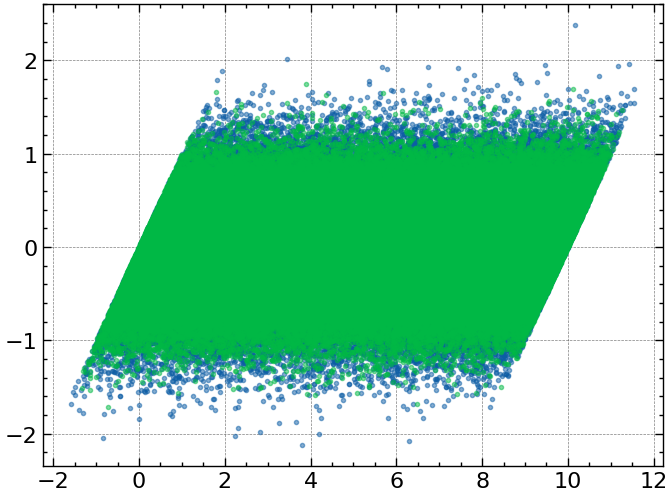

In [18]:
plt.plot(x_north_measured,x_north_noise,'.', alpha=0.5, label='North noise',)
plt.plot(x_south_measured,x_south_noise,'.', alpha=0.5, label='South noise',)
#plt.hist(downgrade_noise, bins=100, alpha=0.5, label='Downgrade noise', density=True)

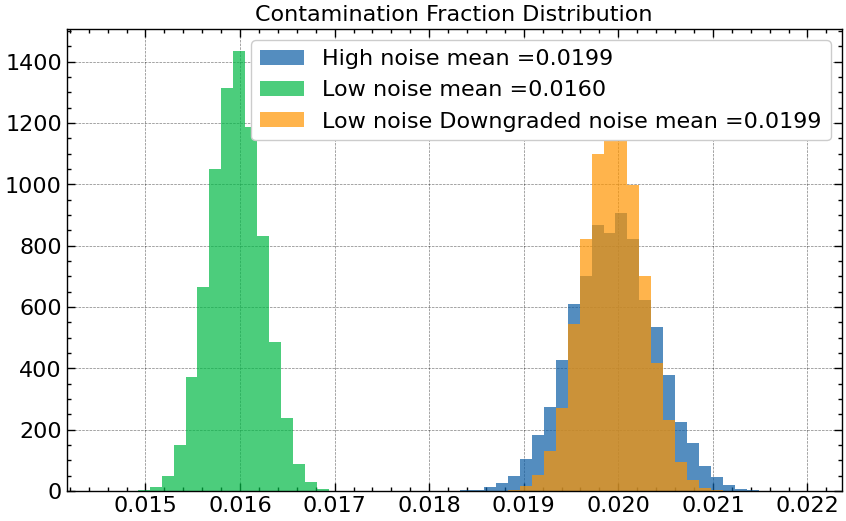

In [19]:
plt.figure(figsize=(10,6))
bins = np.linspace(np.min(outliers),np.max(outliers),60)
plt.hist(outliers[:,0],bins = bins,density=True,alpha=0.7, label=f'High noise mean ={np.mean(outliers[:,0]):.4f}')
plt.hist(outliers[:,1],bins = bins,density=True,alpha=0.7, label=f'Low noise mean ={np.mean(outliers[:,1]):.4f}')
plt.hist(outliers[:,2],bins = bins,density=True,alpha=0.7, label=f'Low noise Downgraded noise mean ={np.mean(outliers[:,2]):.4f}')
plt.title('Contamination Fraction Distribution')
plt.legend()

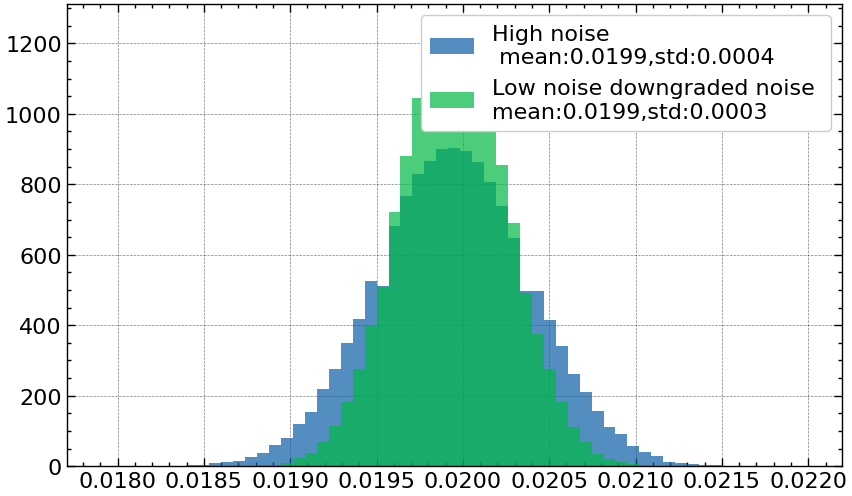

In [20]:
plt.figure(figsize=(10,6))
bins = np.linspace(np.min(outliers[:,0]),np.max(outliers[:,0]),60)
plt.hist(outliers[:,0],bins = bins,density=True,alpha=0.7, label=f'High noise \n mean:{np.mean(outliers[:,0]):.4f},std:{np.std(outliers[:,0]):.4f}')
plt.hist(outliers[:,2],bins = bins,density=True,alpha=0.7, label=f'Low noise downgraded noise \nmean:{np.mean(outliers[:,2]):.4f},std:{np.std(outliers[:,2]):.4f}')
plt.legend()

In [21]:
#KL divergence calculation
from scipy.stats import entropy
from scipy.special import rel_entr
bins = np.linspace(
    min(outliers[:,0].min(), outliers[:,2].min()),
    max(outliers[:,0].max(), outliers[:,2].max()),
    50
)
hist_high,_ = np.histogram(outliers[:,0], bins=bins, density=False)
np.random.choice
hist_low_downgraded,_ = np.histogram(outliers[:,2], bins=bins, density=False)
eps = 1e-10
P = (hist_high+eps)/np.sum(hist_high+eps)
Q = (hist_low_downgraded+eps)/np.sum(hist_low_downgraded+eps)
kl_divergence = entropy(P, Q)
print(f'KL Divergence between high noise and downgraded noise distributions: {kl_divergence}')

KL Divergence between high noise and downgraded noise distributions: 0.19871350496410362


In [22]:
KL_PQ = np.sum(rel_entr(P, Q))  # KL(P || Q)
KL_QP = np.sum(rel_entr(Q, P))  # KL(Q || P)

In [23]:
print(f'KL(P || Q): {KL_PQ:.3f}')
print(f'KL(Q || P): {KL_QP:.3f}')
print(f'Jensen-Shannon Divergence: {(KL_PQ + KL_QP) / 2:.3f}')

KL(P || Q): 0.199
KL(Q || P): 0.097
Jensen-Shannon Divergence: 0.148


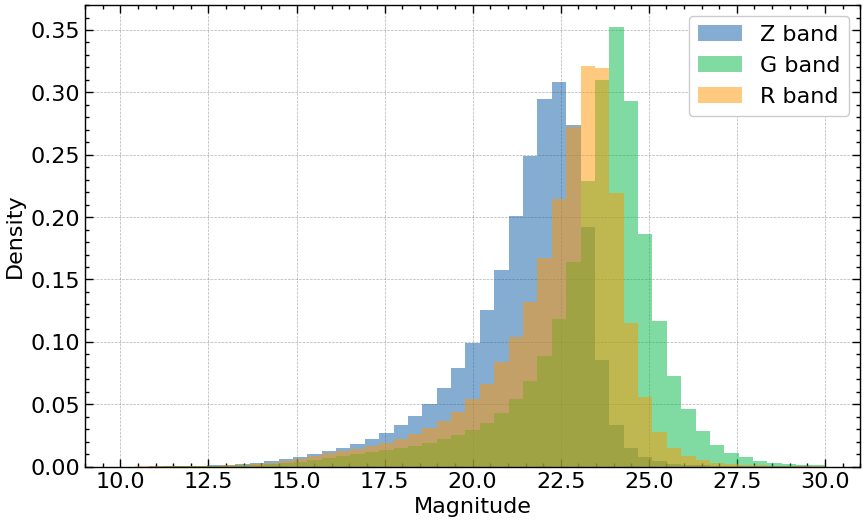

In [24]:
# Convert flux to magnitudes
# Using the standard formula: magnitude = -2.5 * log10(flux) + zeropoint
# Common zeropoint for nanomaggies is 22.5

zeropoint = 22.5
flux_z_mag = -2.5 * np.log10(flux[flux > 0]) + zeropoint
flux_g_mag = -2.5 * np.log10(table['FLUX_G'][g_mask]) + zeropoint
flux_r_mag = -2.5 * np.log10(table['FLUX_R'][r_mask]) + zeropoint

# Plot the magnitude distributions
plt.figure(figsize=(10, 6))
bins_mag = np.linspace(10, 30, 50)
plt.hist(flux_z_mag, bins=bins_mag, alpha=0.5, label='Z band', density=True)
plt.hist(flux_g_mag, bins=bins_mag, alpha=0.5, label='G band', density=True)
plt.hist(flux_r_mag, bins=bins_mag, alpha=0.5, label='R band', density=True)
plt.xlabel('Magnitude')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)

In [25]:
# using copula


In [25]:
import numpy as np

# example data
f = np.random.uniform(0.1, 10, 10000)      # flux
sigma = 0.1 + 0.5 / f                      # heteroskedastic noise
delta_f = np.random.normal(0, sigma)      # residuals
from statsmodels.distributions.empirical_distribution import ECDF
F_f = ECDF(f)

In [26]:
from scipy.interpolate import UnivariateSpline
bins = np.logspace(np.log10(f.min()), np.log10(f.max()), 30)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
sigma_med = []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (f > lo) & (f < hi)
    sigma_med.append(np.std(delta_f[mask]))

sigma_med = np.array(sigma_med)
sigma_spline = UnivariateSpline(bin_centers, sigma_med, s=0.5)

# normalized residuals
r = delta_f / sigma_spline(f)

In [27]:
F_r = ECDF(r)
u = F_f(f)   # uniform(0,1)
v = F_r(r)   # uniform(0,1)
from scipy.stats import norm

z_u = norm.ppf(u)
z_v = norm.ppf(v)

In [28]:
rho = np.corrcoef(z_u, z_v)[0, 1]
print("Copula correlation:", rho)

Copula correlation: nan


/user/animesh.sah/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:2742: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


In [29]:
f_south = np.array([1.0, 2.0, 5.0])
u_south = F_f(f_south)
z_u_south = norm.ppf(u_south)
z_v_new = rho * z_u_south + np.sqrt(1 - rho**2) * np.random.randn(len(z_u_south))
v_new = norm.cdf(z_v_new)
# inverse residual CDF
r_new = np.quantile(r, v_new)

# scale by North sigma model
sigma_north = sigma_spline(f_south) * 2.0  # example: North is noisier
delta_f_new = r_new * sigma_north

f_degraded = f_south + delta_f_new


ValueError: Quantiles must be in the range [0, 1]

In [ ]:
#heteroskedastic noise addition 
##now the noise depends on the flux value
cut = 18
n_samples_north = 10000
n_samples_south = 20000
sd_north = 0.5
sd_south = 0.1
flux_val = np.random.uniform(0,22,10000)





## Regularized Q-Q mapping

In [ ]:
# from scipy import stats, interpolate
# np.random.seed(42)
# n_objects = 5000
# f_true = np.exp(np.random.uniform(-2, 6, n_objects))  # 0.1 to 100 nanomaggies
# sigma_south = 0.1 * np.sqrt(f_true) + 0.05
# f_obs_south = f_true + np.random.normal(0, sigma_south)
# sigma_north = 0.2 * np.sqrt(f_true) + 0.1
# skew_noise = np.random.exponential(1, n_objects) - 1
# f_obs_north = f_true + sigma_north * skew_noise

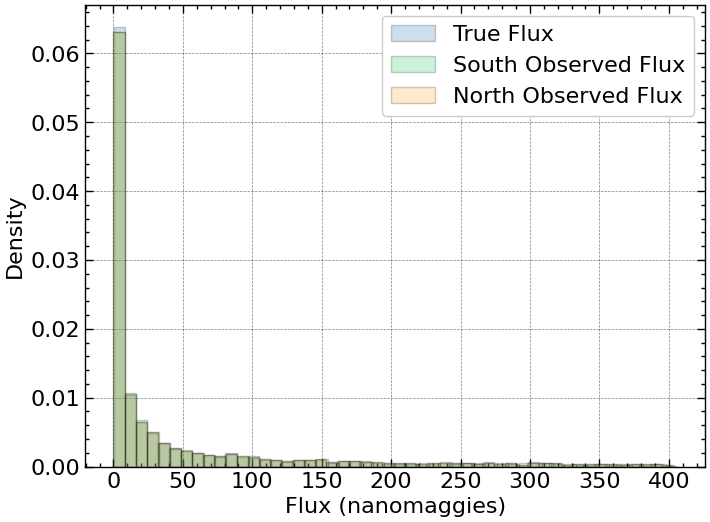

In [ ]:
# plt.hist(f_true, bins=50, alpha=0.2, label='True Flux', density=True,edgecolor='black')
# plt.hist(f_obs_south, bins=50, alpha=0.2, label='South Observed Flux', density=True,edgecolor='black')
# plt.hist(f_obs_north, bins=50, alpha=0.2, label='North Observed Flux', density=True,edgecolor='black')
# plt.xlabel('Flux (nanomaggies)')
# plt.ylabel('Density')
# plt.legend()

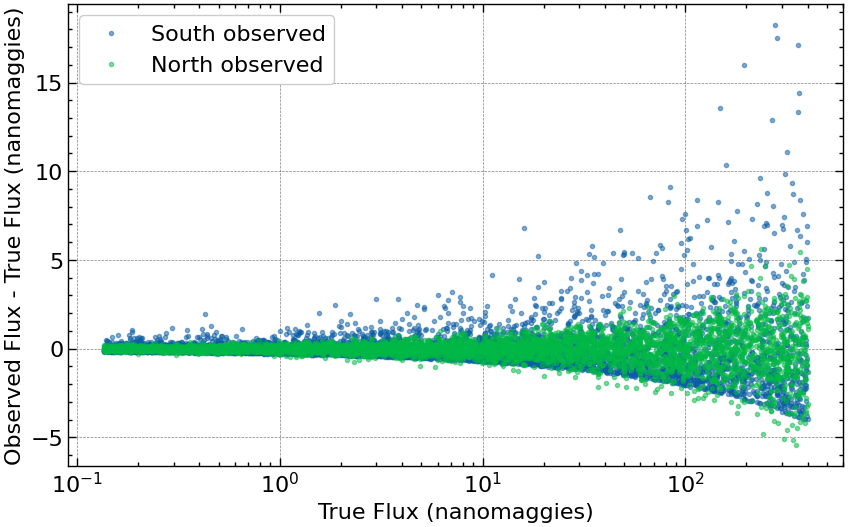

In [ ]:
# plt.figure(figsize=(10,6))
# plt.plot(f_true, f_obs_north-f_true, '.', alpha=0.5, label='South observed')
# plt.plot(f_true, f_obs_south-f_true, '.', alpha=0.5, label='North observed')
# plt.xscale('log')
# plt.xlabel('True Flux (nanomaggies)')
# plt.ylabel('Observed Flux - True Flux (nanomaggies)')
# plt.legend()

In [ ]:
def create_flux_bins(f_true, n_bins=10):
    """Create adaptive flux bins with approximately equal counts"""
    quantiles = np.linspace(0, 1, n_bins + 1)
    bin_edges = np.quantile(f_true, quantiles)
    # Ensure monotonic and remove duplicates
    bin_edges = np.unique(bin_edges)
    return bin_edges

# Create bins
bin_edges = create_flux_bins(f_true, n_bins=8)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

print(f"Bin edges: {bin_edges}")
print(f"Objects per bin: {[np.sum((f_true >= bin_edges[i]) & (f_true < bin_edges[i+1])) for i in range(len(bin_edges)-1)]}")

Bin edges: [1.35347881e-01 3.53037760e-01 9.52089722e-01 2.62907521e+00
 7.38956658e+00 1.99052625e+01 5.37749085e+01 1.44823461e+02
 4.02518632e+02]
Objects per bin: [625, 625, 625, 625, 625, 625, 625, 624]


In [ ]:
# def build_qq_mapper(f_true, f_obs_south, f_obs_north, bin_edges):
#     """
#     Build Q-Q mapping from South to North survey errors
    
#     Returns function that maps South observed flux to degraded flux
#     """
#     n_bins = len(bin_edges) - 1
#     qq_functions = []
    
#     for i in range(n_bins):
#         # Select objects in this flux bin
#         mask = (f_true >= bin_edges[i]) & (f_true < bin_edges[i+1])
        
#         if mask.sum() < 20:  # Skip bins with too few objects
#             qq_functions.append(None)
#             continue
        
#         # Compute residuals
#         residual_south = f_obs_south[mask] - f_true[mask]
#         residual_north = f_obs_north[mask] - f_true[mask]
        
#         # Sort residuals
#         residual_south_sorted = np.sort(residual_south)
#         residual_north_sorted = np.sort(residual_north)
        
#         # Create interpolator: South quantile -> North residual
#         # Use empirical CDF positions
#         quantiles = np.linspace(0, 1, len(residual_south_sorted))
        
#         # Interpolate with extrapolation
#         qq_func = interpolate.interp1d(
#             residual_south_sorted, 
#             residual_north_sorted,
#             kind='linear',
#             bounds_error=False,
#             fill_value=(residual_north_sorted[0], residual_north_sorted[-1])
#         )
        
#         qq_functions.append(qq_func)
    
#     return qq_functions, bin_edges

# # Build the mapper
# qq_functions, bin_edges = build_qq_mapper(f_true, f_obs_south, f_obs_north, bin_edges)

NameError: name 'bin_edges' is not defined

In [ ]:
# def degrade_flux(f_obs_south, f_true_est, qq_functions, bin_edges):
#     """
#     Degrade South observations to match North error distribution
    
#     Parameters:
#     -----------
#     f_obs_south : array
#         Observed fluxes from South survey
#     f_true_est : array  
#         Estimated true fluxes (e.g., from stacking or model)
#     qq_functions : list
#         Q-Q mapping functions from build_qq_mapper
#     bin_edges : array
#         Flux bin edges
        
#     Returns:
#     --------
#     f_degraded : array
#         Degraded fluxes matching North error distribution
#     """
#     f_degraded = np.zeros_like(f_obs_south)
    
#     for i in range(len(bin_edges) - 1):
#         # Find objects in this bin
#         mask = (f_true_est >= bin_edges[i]) & (f_true_est < bin_edges[i+1])
        
#         if not mask.any() or qq_functions[i] is None:
#             # No mapping available, keep original
#             f_degraded[mask] = f_obs_south[mask]
#             continue
        
#         # Compute South residuals
#         residual_south = f_obs_south[mask] - f_true_est[mask]
        
#         # Map to North residuals via Q-Q function
#         residual_north = qq_functions[i](residual_south)
        
#         # Add mapped residuals back to true flux
#         f_degraded[mask] = f_true_est[mask] + residual_north
    
#     return f_degraded

# # Apply degradation
# # In practice, f_true would be estimated from data
# # Here we use true values for demonstration
# f_degraded = degrade_flux(f_obs_south, f_true, qq_functions, bin_edges)

NameError: name 'qq_functions' is not defined

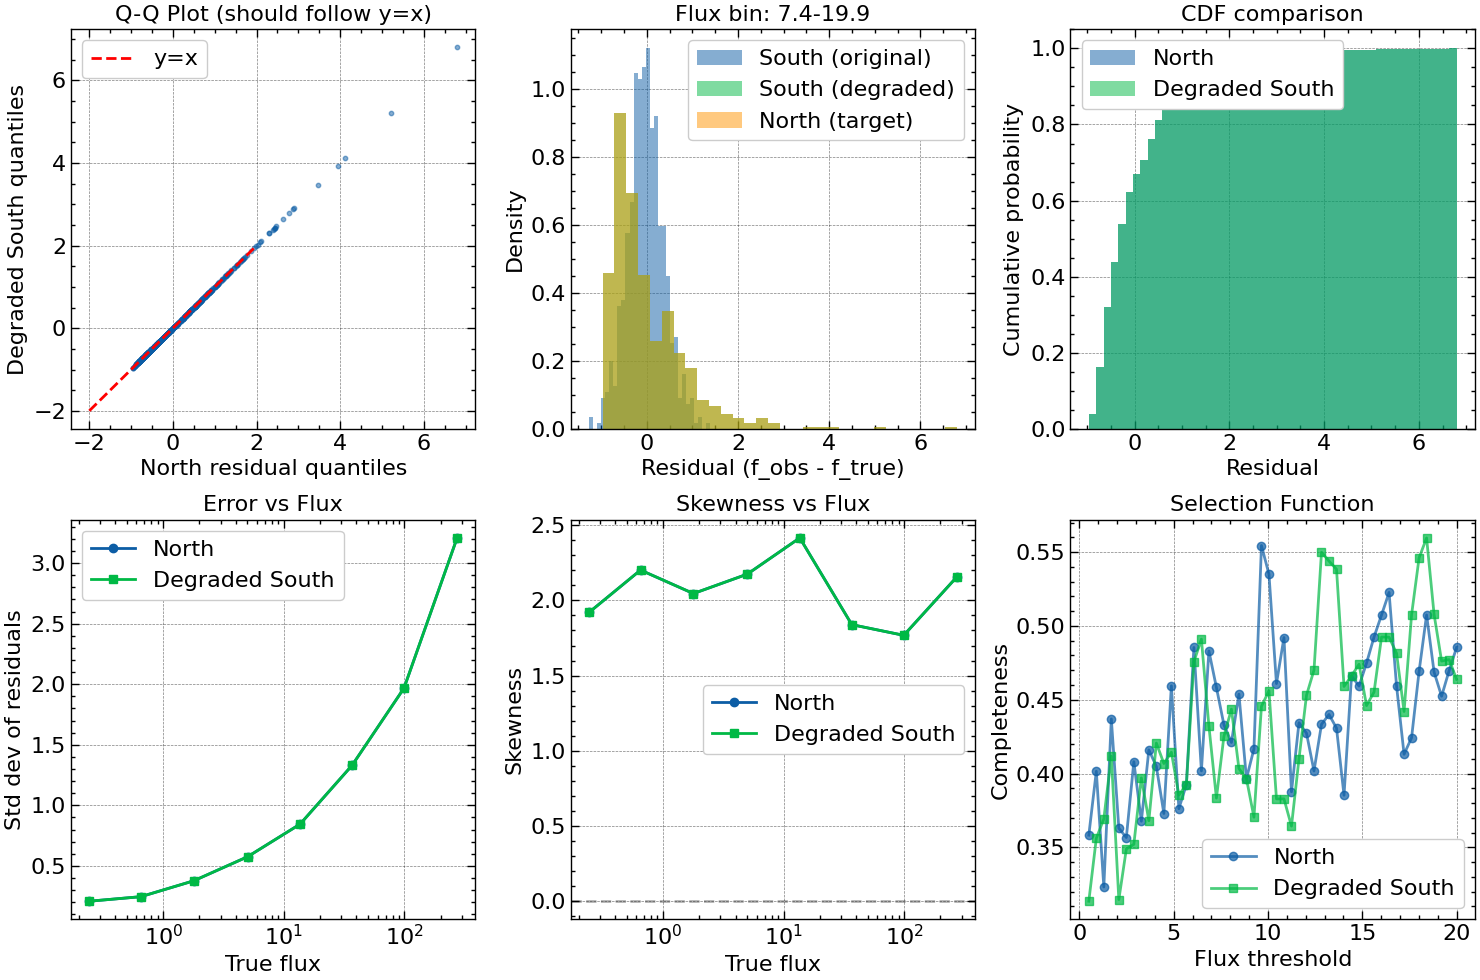

Validation complete! Check that:
1. Q-Q plot follows y=x line
2. CDFs overlap closely
3. Moments (std, skewness) match across flux bins
4. Selection functions are consistent


In [ ]:
# # Validation: Compare error distributions

# fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# # Select a flux bin for detailed comparison
# bin_idx = 4
# mask = (f_true >= bin_edges[bin_idx]) & (f_true < bin_edges[bin_idx+1])

# # 1. Q-Q plot
# residual_south = f_obs_south[mask] - f_true[mask]
# residual_north = f_obs_north[mask] - f_true[mask]
# residual_degraded = f_degraded[mask] - f_true[mask]

# axes[0, 0].scatter(np.sort(residual_north), np.sort(residual_degraded), 
#                    alpha=0.5, s=10)
# axes[0, 0].plot([-2, 2], [-2, 2], 'r--', label='y=x')
# axes[0, 0].set_xlabel('North residual quantiles')
# axes[0, 0].set_ylabel('Degraded South quantiles')
# axes[0, 0].set_title('Q-Q Plot (should follow y=x)')
# axes[0, 0].legend()

# # 2. Residual distributions
# axes[0, 1].hist(residual_south, bins=30, alpha=0.5, 
#                 label='South (original)', density=True)
# axes[0, 1].hist(residual_degraded, bins=30, alpha=0.5, 
#                 label='South (degraded)', density=True)
# axes[0, 1].hist(residual_north, bins=30, alpha=0.5, 
#                 label='North (target)', density=True)
# axes[0, 1].set_xlabel('Residual (f_obs - f_true)')
# axes[0, 1].set_ylabel('Density')
# axes[0, 1].set_title(f'Flux bin: {bin_edges[bin_idx]:.1f}-{bin_edges[bin_idx+1]:.1f}')
# axes[0, 1].legend()

# # 3. Cumulative distributions
# axes[0, 2].hist(residual_north, bins=50, alpha=0.5, 
#                 cumulative=True, density=True, label='North')
# axes[0, 2].hist(residual_degraded, bins=50, alpha=0.5,
#                 cumulative=True, density=True, label='Degraded South')
# axes[0, 2].set_xlabel('Residual')
# axes[0, 2].set_ylabel('Cumulative probability')
# axes[0, 2].set_title('CDF comparison')
# axes[0, 2].legend()

# # 4. Moment matching across bins
# moments = {'mean': [], 'std': [], 'skew': [], 'kurt': []}
# for survey, data in [('North', f_obs_north), ('Degraded', f_degraded)]:
#     for i in range(len(bin_edges) - 1):
#         mask = (f_true >= bin_edges[i]) & (f_true < bin_edges[i+1])
#         if mask.sum() < 20:
#             continue
#         resid = data[mask] - f_true[mask]
#         moments['mean'].append({'survey': survey, 'bin': i, 
#                                 'value': np.mean(resid)})
#         moments['std'].append({'survey': survey, 'bin': i, 
#                                'value': np.std(resid)})
#         moments['skew'].append({'survey': survey, 'bin': i,
#                                 'value': stats.skew(resid)})

# # Plot standard deviation vs flux
# north_std = [m['value'] for m in moments['std'] if m['survey'] == 'North']
# deg_std = [m['value'] for m in moments['std'] if m['survey'] == 'Degraded']
# axes[1, 0].plot(bin_centers[:len(north_std)], north_std, 'o-', label='North')
# axes[1, 0].plot(bin_centers[:len(deg_std)], deg_std, 's-', label='Degraded South')
# axes[1, 0].set_xlabel('True flux')
# axes[1, 0].set_ylabel('Std dev of residuals')
# axes[1, 0].set_xscale('log')
# axes[1, 0].legend()
# axes[1, 0].set_title('Error vs Flux')

# # 5. Skewness comparison  
# north_skew = [m['value'] for m in moments['skew'] if m['survey'] == 'North']
# deg_skew = [m['value'] for m in moments['skew'] if m['survey'] == 'Degraded']
# axes[1, 1].plot(bin_centers[:len(north_skew)], north_skew, 'o-', label='North')
# axes[1, 1].plot(bin_centers[:len(deg_skew)], deg_skew, 's-', label='Degraded South')
# axes[1, 1].axhline(0, color='k', linestyle='--', alpha=0.3)
# axes[1, 1].set_xlabel('True flux')
# axes[1, 1].set_ylabel('Skewness')
# axes[1, 1].set_xscale('log')
# axes[1, 1].legend()
# axes[1, 1].set_title('Skewness vs Flux')

# # 6. Selection function
# thresholds = np.linspace(0.5, 20, 50)
# completeness_north = []
# completeness_degraded = []

# for thresh in thresholds:
#     # True completeness at this flux
#     mask_flux = (f_true >= thresh * 0.9) & (f_true <= thresh * 1.1)
#     if mask_flux.sum() > 0:
#         comp_n = np.mean(f_obs_north[mask_flux] > thresh)
#         comp_d = np.mean(f_degraded[mask_flux] > thresh)
#         completeness_north.append(comp_n)
#         completeness_degraded.append(comp_d)

# axes[1, 2].plot(thresholds[:len(completeness_north)], completeness_north, 
#                 'o-', label='North', alpha=0.7)
# axes[1, 2].plot(thresholds[:len(completeness_degraded)], completeness_degraded,
#                 's-', label='Degraded South', alpha=0.7)
# axes[1, 2].set_xlabel('Flux threshold')
# axes[1, 2].set_ylabel('Completeness')
# axes[1, 2].set_title('Selection Function')
# axes[1, 2].legend()

# plt.tight_layout()
# plt.savefig('qq_mapping_validation.png', dpi=150, bbox_inches='tight')
# plt.show()

# print("Validation complete! Check that:")
# print("1. Q-Q plot follows y=x line")
# print("2. CDFs overlap closely")  
# print("3. Moments (std, skewness) match across flux bins")
# print("4. Selection functions are consistent")

## KD Tree

Building Noise Library from North data...
Finding 20 nearest neighbors for each South object...


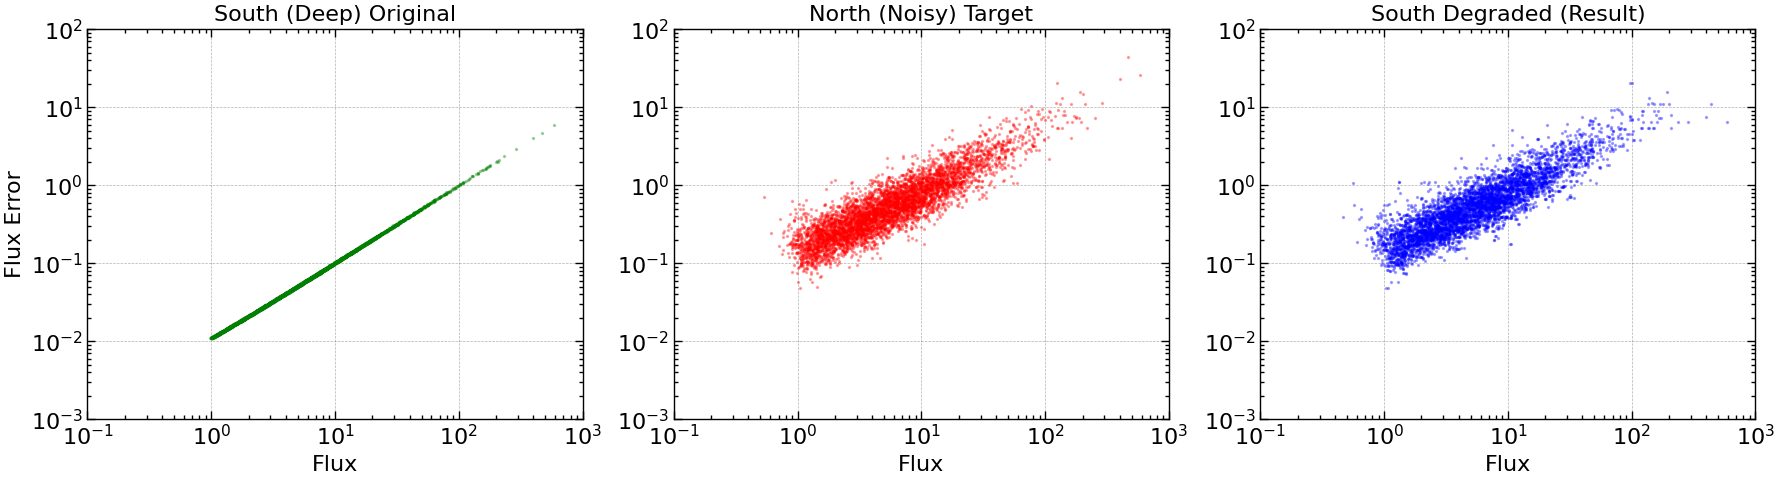

Median Error (North Original): 0.4919
Median Error (South Degraded): 0.5012


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.neighbors import NearestNeighbors

# # ==========================================
# # 1. GENERATE MOCK DATA
# # ==========================================
# def generate_mock_data(n_samples=10000):
#     """
#     Generates synthetic 'True' fluxes and observes them in two surveys:
#     - South: Very deep, low noise.
#     - North: Shallower, complex heteroskedastic noise with outliers.
#     """
#     np.random.seed(42)
    
#     # 1. True Fluxes (Power law distribution to mimic galaxy counts)
#     # Range: 10^-1 to 10^3 nanomaggies
#     true_fluxes = np.random.pareto(a=2.0, size=n_samples) + 0.1
#     true_fluxes = true_fluxes * 10 
    
#     # 2. Simulate South (Deep) Survey
#     # Simple Gaussian noise, very small errors (approx 1% of flux or floor)
#     sigma_S = 0.01 * true_fluxes + 0.001 
#     noise_S = np.random.normal(0, sigma_S)
#     flux_S = true_fluxes + noise_S
    
#     # 3. Simulate North (Noisy) Survey - The Target Distribution
#     # Complex noise model: Flux dependent + Random Depth Variation (Scatter)
    
#     # Base error curve (flux dependent)
#     base_sigma_N = 0.1 * np.sqrt(true_fluxes) + 0.05 * true_fluxes
    
#     # Depth Variation: Multiply base error by a random factor 
#     # (Simulates some parts of the sky being shallower/noisier than others)
#     depth_scatter = np.random.lognormal(mean=0, sigma=0.4, size=n_samples)
#     sigma_N = base_sigma_N * depth_scatter
    
#     # Add non-Gaussian noise (Student's t-like tails)
#     # We simulate this by mixing widths
#     noise_N = np.random.normal(0, sigma_N)
#     flux_N = true_fluxes + noise_N
    
#     return flux_S, sigma_S, flux_N, sigma_N

# # ==========================================
# # 2. THE DEGRADATION ALGORITHM (Method A)
# # ==========================================
# def degrade_south_to_north(flux_S, sigma_S, flux_N, sigma_N, k_neighbors=20):
#     """
#     Degrades South data to match North noise properties using Nearest Neighbors.
#     """
#     print("Building Noise Library from North data...")
    
#     # Format data for sklearn (requires 2D array)
#     # We match strictly on FLUX. 
#     # Log-space matching is usually better for power-law distributions.
#     X_north = np.log10(np.clip(flux_N, 1e-5, None)).reshape(-1, 1)
#     X_south = np.log10(np.clip(flux_S, 1e-5, None)).reshape(-1, 1)
    
#     # Build Tree
#     nbrs = NearestNeighbors(n_neighbors=k_neighbors, algorithm='auto').fit(X_north)
    
#     # Find neighbors for every South object
#     print(f"Finding {k_neighbors} nearest neighbors for each South object...")
#     distances, indices = nbrs.kneighbors(X_south)
    
#     # Arrays to hold new properties
#     flux_S_degraded = np.zeros_like(flux_S)
#     sigma_S_degraded = np.zeros_like(sigma_S)
    
#     n_obj = len(flux_S)
    
#     # Vectorized Noise Injection
#     # 1. Randomly choose ONE neighbor index for each South object
#     random_selection = np.random.randint(0, k_neighbors, size=n_obj)
#     # Advanced indexing to grab the specific neighbor ID for each row
#     chosen_neighbor_indices = indices[np.arange(n_obj), random_selection]
    
#     # 2. Retrieve the Noise Properties of that neighbor
#     target_sigma = sigma_N[chosen_neighbor_indices]
    
#     # 3. Calculate Noise to Add (Quadrature difference)
#     # If South noise > Target noise (rare), we add 0 noise.
#     var_diff = np.square(target_sigma) - np.square(sigma_S)
#     var_diff[var_diff < 0] = 0 # Clip negative values
#     sigma_to_add = np.sqrt(var_diff)
    
#     # 4. Generate Random Noise
#     # You can change 'normal' to 'standard_t' if you suspect heavy tails in the kernel itself
#     noise_injection = np.random.normal(0, sigma_to_add)
    
#     # 5. Apply
#     flux_S_degraded = flux_S + noise_injection
#     sigma_S_degraded = target_sigma # Inherit the reported error of the neighbor
    
#     return flux_S_degraded, sigma_S_degraded

# # ==========================================
# # 3. RUN & VALIDATE
# # ==========================================

# # A. Generate Data
# f_S, sig_S, f_N, sig_N = generate_mock_data(n_samples=5000)

# # B. Run Degradation
# f_S_deg, sig_S_deg = degrade_south_to_north(f_S, sig_S, f_N, sig_N)

# # C. Visualization
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# # Plot 1: The South (Input) - Clean and tight
# axes[0].scatter(f_S, sig_S, alpha=0.3, s=2, color='green', label='South (Input)')
# axes[0].set_title("South (Deep) Original")
# axes[0].set_xlabel("Flux")
# axes[0].set_ylabel("Flux Error")
# axes[0].set_xscale('log')
# axes[0].set_yscale('log')
# axes[0].set_xlim(0.1, 1000)
# axes[0].set_ylim(0.001, 100)
# axes[0].grid(True, alpha=0.3)

# # Plot 2: The North (Target) - Messy and scattered
# axes[1].scatter(f_N, sig_N, alpha=0.3, s=2, color='red', label='North (Target)')
# axes[1].set_title("North (Noisy) Target")
# axes[1].set_xlabel("Flux")
# axes[1].set_xscale('log')
# axes[1].set_yscale('log')
# axes[1].set_xlim(0.1, 1000)
# axes[1].set_ylim(0.001, 100)
# axes[1].grid(True, alpha=0.3)

# # Plot 3: The South Degraded (Result) - Should look like North
# axes[2].scatter(f_S_deg, sig_S_deg, alpha=0.3, s=2, color='blue', label='South Degraded')
# axes[2].set_title("South Degraded (Result)")
# axes[2].set_xlabel("Flux")
# axes[2].set_xscale('log')
# axes[2].set_yscale('log')
# axes[2].set_xlim(0.1, 1000)
# axes[2].set_ylim(0.001, 100)
# axes[2].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Verification Stats
# print(f"Median Error (North Original): {np.median(sig_N):.4f}")
# print(f"Median Error (South Degraded): {np.median(sig_S_deg):.4f}")

# Conditional Normalizing Flows


In [ ]:
np.percentile(table['FLUX_Z'][z_mask],98)

358.0761230468749

In [ ]:
from scipy.stats import gaussian_kde
kde = gaussian_kde(table['FLUX_R'][r_mask & (table['FLUX_R'] < np.percentile(table['FLUX_R'][r_mask],98))],bw_method=0.5)
samples = kde.resample(500).flatten()
samples = np.clip(samples, 0, None)
y_samples=kde.evaluate(samples)
samples_sorted=np.sort(samples)
arg=np.argsort(samples)
y_samples_sorted= y_samples[arg]


#plt.hist(table['FLUX_Z'][z_mask], bins=bins, alpha=0.5, label='Z band', density=True)


In [44]:
north_band_r = north_stats[north_stats['band'] =='R']
south_band_r = south_stats[south_stats['band'] =='R']

KeyError: 'band'

In [ ]:
samples = kde.resample(50000).flatten()
len((samples[(samples>band_stats_north['flux_bin_center'].min()) & (samples<band_stats_north['flux_bin_center'].max())] ))

29302

In [ ]:
from scipy.interpolate import UnivariateSpline

sigma_north_spline = UnivariateSpline(
    north_band_r['flux_bin_center'],
    band_stats_north['sigma_median'],
    s=0.5
)

sigma_south_spline = UnivariateSpline(
    south_band_r['flux_bin_center'],
    south_band_r['sigma_median'],
    s=0.5   )



(array([25958.,  1761.,   492.,   313.,   224.,   163.,   146.,   101.,
           83.,    26.]),
 array([2.40482610e-02, 2.84088574e+01, 5.67936664e+01, 8.51784755e+01,
        1.13563285e+02, 1.41948094e+02, 1.70332903e+02, 1.98717712e+02,
        2.27102521e+02, 2.55487330e+02, 2.83872139e+02]),
 <BarContainer object of 10 artists>)

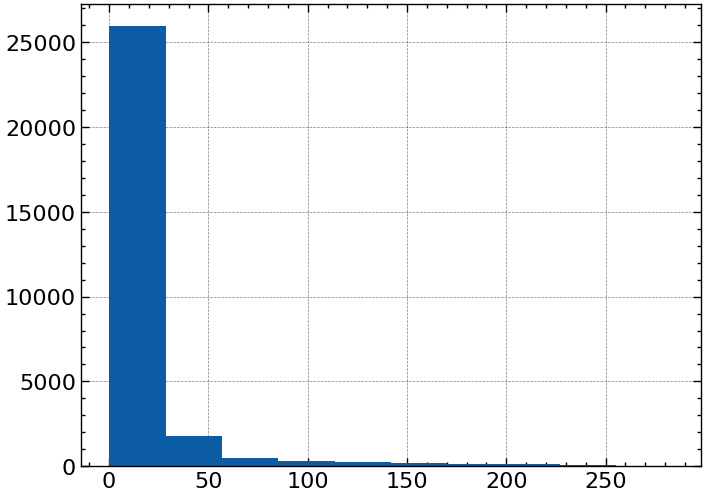

In [ ]:
plt.hist(f_true)

In [ ]:
sigma_south

array([ 0.07897407,  0.07664363,  0.07861612, ...,  0.05068182,
        0.0580832 , -0.00278083])

In [43]:

min_flux = band_stats_north['flux_bin_center'].min()
max_flux = band_stats_north['flux_bin_center'].max()



f_true = samples[(samples>south_band_r['flux_bin_center'].min()) & (samples<south_band_r['flux_bin_center'].max())] 
n_objects = len(f_true)
sigma_south = sigma_south_spline(f_true)
sigma_north = sigma_north_spline(f_true)

f_obs_south = f_true + np.random.normal(0, sigma_south)
#skew_noise = np.random.exponential(1, n_objects) - 1
f_obs_north = f_true + np.random.normal(0, sigma_north)



NameError: name 'south_band_r' is not defined

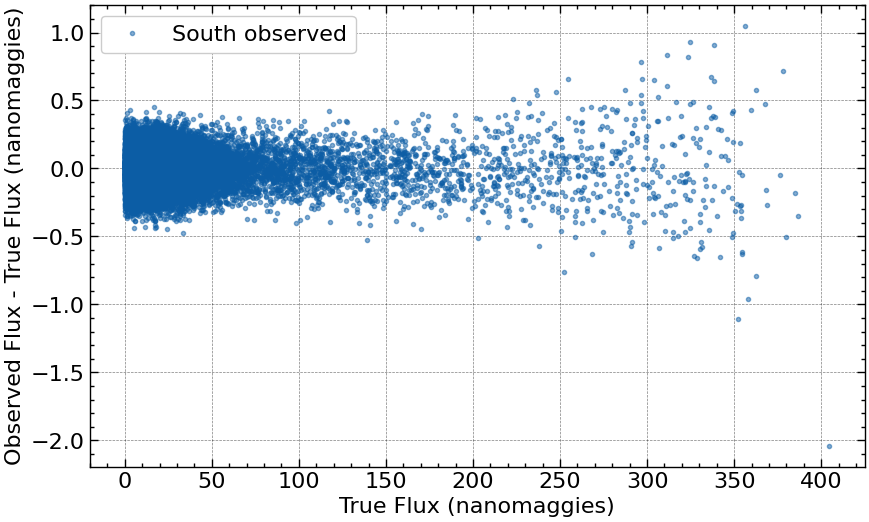

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(f_true, f_obs_north-f_true, '.', alpha=0.5, label='South observed')
#plt.plot(f_true, f_obs_south, '.', alpha=0.5, label='North observed')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('True Flux (nanomaggies)')
plt.ylabel('Observed Flux - True Flux (nanomaggies)')
plt.legend()

In [77]:
file_path= '/user/animesh.sah/DESI_PECVEL/flux_error_stats_DR9/flux_error_stats_north_log.fits'
from astropy.table import Table
north_stats = Table.read(file_path)
file_path= '/user/animesh.sah/DESI_PECVEL/flux_error_stats_DR9/flux_error_stats_south_log.fits'
south_stats = Table.read(file_path)


In [78]:
for band in ['G','R','Z']:
    clean_north_stats = north_stats[f'bin_center_FLUX_{band}'][np.isfinite(north_stats[f'sigma_median_FLUX_{band}'])]
    clean_south_stats = south_stats[f'bin_center_FLUX_{band}'][np.isfinite(south_stats[f'sigma_median_FLUX_{band}'])]
    valid_range_min = max(clean_north_stats.min(), clean_south_stats.min())
    valid_range_max = min(clean_north_stats.max(), clean_south_stats.max())
    print(valid_range_min, valid_range_max)


6.142379598663943e-05 58951.94676341158
0.00034666937745379703 73583.48010410552
0.0011371871587446908 50342.71203983347


In [79]:
directory = 'south'  # or 'north'   
cols1 = ['RA', 'DEC', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1']
fits_path = f'/storage/shadab/data/legacy_survey/dr9/south/sweep/9.0/sweep-000m005-010p000.fits'
dr9_chunk = Table(fitsio.FITS(fits_path)[1].read(columns=cols1))

for i in ['R']:
    flux = np.array(dr9_chunk[f'FLUX_{i}'])
    flux_new = flux.copy()
    if directory == 'south' and 'W1' not in i:

        with open(f'../flux_error_stats_DR9/spline_north_{i}.pkl', 'rb') as f:
            north_err_spline = pickle.load(f)
        with open(f'../flux_error_stats_DR9/spline_south_{i}.pkl', 'rb') as f:
            south_err_spline = pickle.load(f)

        # Get spline valid ranges
        clean_north_stats = north_stats[f'bin_center_FLUX_{i}'][np.isfinite(north_stats[f'sigma_median_FLUX_{i}'])]
        clean_south_stats = south_stats[f'bin_center_FLUX_{i}'][np.isfinite(south_stats[f'sigma_median_FLUX_{i}'])]
        valid_range_min = max(clean_north_stats.min(), clean_south_stats.min())
        valid_range_max = min(clean_north_stats.max(), clean_south_stats.max())
        # Only apply correction where flux is in valid range
        in_range = (flux >= valid_range_min) & (flux <= valid_range_max)
        sigma_south = south_err_spline(flux[in_range])
        sigma_north = north_err_spline(flux[in_range])
        flux_new[in_range] += np.random.normal(0,np.sqrt(sigma_north**2 - sigma_south**2))

NameError: name 'pickle' is not defined

In [152]:
np.sqrt(sigma_north**2 - sigma_south**2)

array([0.05935216, 0.06965686, 0.05956489, ..., 0.05973325, 0.06844198,
       0.0584159 ])

(array([   349.,    396.,    493.,    589.,    704.,    829.,    976.,
          1227.,   1435.,   1706.,   2025.,   2501.,   3009.,   3725.,
          4553.,   5393.,   6529.,   7893.,   9482.,  11315.,  13594.,
         16018.,  19210.,  22742.,  26390.,  31221.,  35776.,  41097.,
         47752.,  53993.,  61330.,  69466.,  77741.,  87051.,  96507.,
        106473., 116489., 126978., 137945., 147413., 158054., 167525.,
        176029., 184794., 192419., 198441., 202989., 207508., 210056.,
        212605., 219180., 210211., 207386., 204111., 198158., 191576.,
        184375., 176380., 167265., 156558., 146861., 137913., 126357.,
        116460., 106377.,  96811.,  87078.,  78121.,  69230.,  61563.,
         54675.,  47618.,  41207.,  35959.,  30738.,  26163.,  22624.,
         18882.,  16342.,  13580.,  11241.,   9507.,   7905.,   6642.,
          5469.,   4528.,   3679.,   3001.,   2534.,   2159.,   1698.,
          1457.,   1149.,    984.,    811.,    712.,    581.,    488.,
      

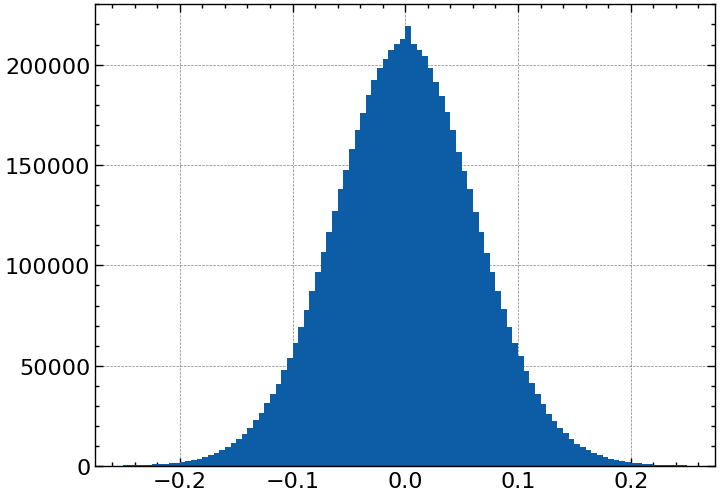

In [170]:
plt.hist(flux_new-flux,bins=100,range=(-0.25,0.25))

(array([2.35000e+02, 3.35300e+03, 2.71950e+04, 1.38857e+05, 3.97543e+05,
        7.61004e+05, 9.56230e+05, 8.60293e+05, 6.32894e+05, 4.40177e+05,
        3.13488e+05, 2.31818e+05, 1.78054e+05, 1.43342e+05, 1.18588e+05,
        1.00684e+05, 8.56920e+04, 7.43200e+04, 6.53240e+04, 5.80430e+04,
        5.12490e+04, 4.64950e+04, 4.17170e+04, 3.78560e+04, 3.46430e+04,
        3.17480e+04, 2.90020e+04, 2.70510e+04, 2.48350e+04, 2.30170e+04,
        2.16210e+04, 2.00870e+04, 1.90710e+04, 1.77650e+04, 1.62560e+04,
        1.58320e+04, 1.47560e+04, 1.40930e+04, 1.32680e+04, 1.24960e+04,
        1.17610e+04, 1.13170e+04, 1.09480e+04, 1.04500e+04, 9.93200e+03,
        9.39600e+03, 9.11400e+03, 8.58700e+03, 8.42900e+03, 8.03800e+03,
        7.78500e+03, 7.33300e+03, 7.13700e+03, 6.77300e+03, 6.63500e+03,
        6.41500e+03, 6.21500e+03, 5.99800e+03, 5.87800e+03, 5.60000e+03,
        5.39500e+03, 5.15500e+03, 5.02800e+03, 4.78300e+03, 4.81600e+03,
        4.66400e+03, 4.31000e+03, 4.32900e+03, 4.14

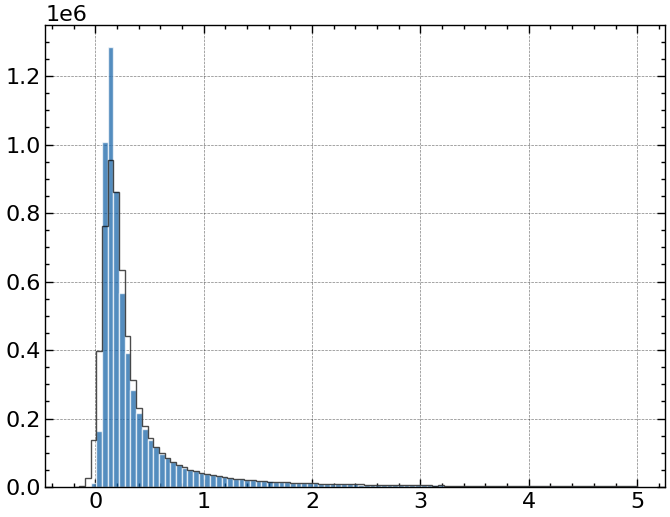

In [176]:
bins = np.linspace(-0.2,5,100)
plt.hist(flux,bins=bins,range=(0,2),alpha=0.7,edgecolor='w')
plt.hist(flux_new,bins=bins,range=(-1,2),alpha=0.7,edgecolor='black',histtype='step')
# plt.xscale('log')

KeyError: 'bin_center_FLUX_G'

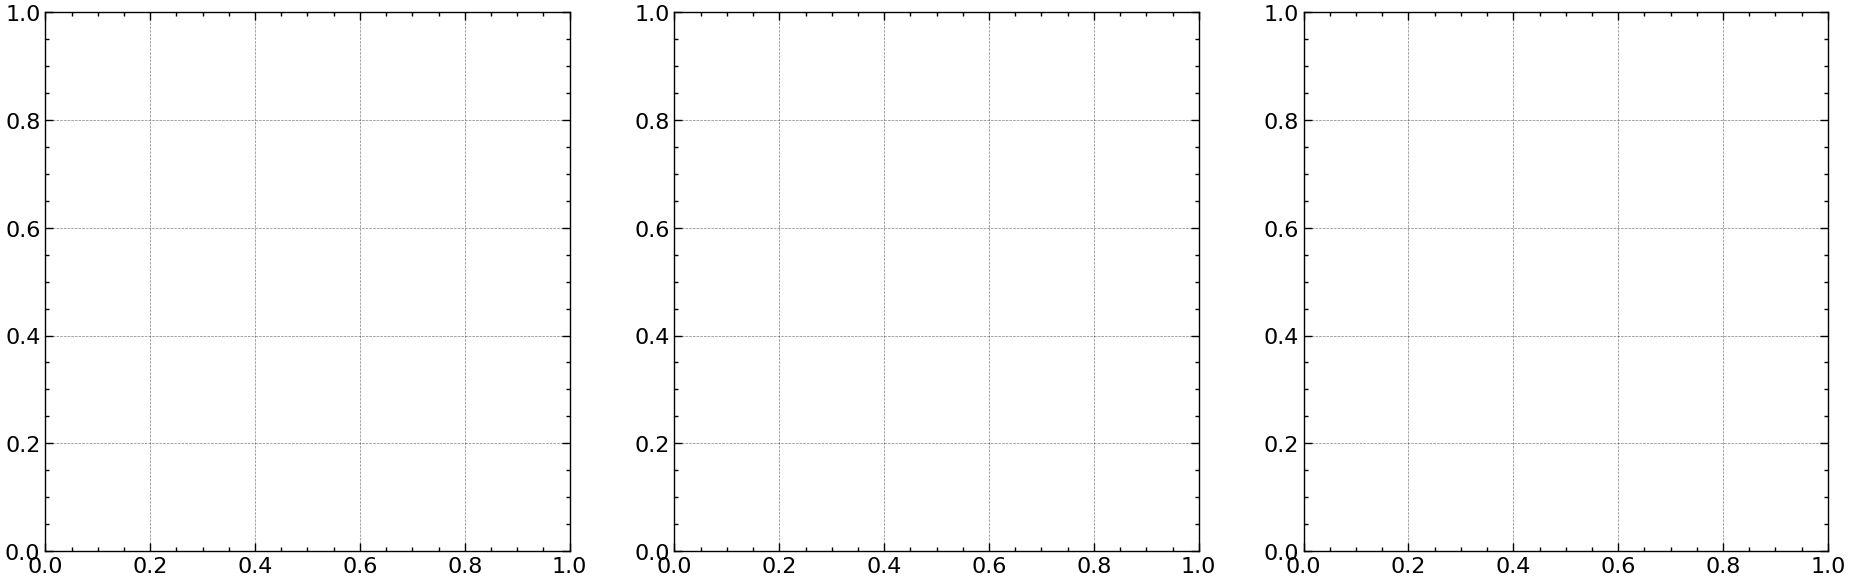

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(23, 7))
colors = {'G': 'green', 'R': 'red', 'Z': 'gray'}
for idx, band in enumerate(['G', 'R', 'Z']):
    ax = axes[idx]    
    ax.plot(
        north_stats[f'bin_center_FLUX_{band}'],
        north_stats[f'sigma_median_FLUX_{band}'],'--',
        lw=2,
        label='North median',
        
        color=colors[band]
    )
    ax.plot(
        south_stats[f'bin_center_FLUX_{band}'],
        south_stats[f'sigma_median_FLUX_{band}'],'-',
        lw=2,
        label='South median',
        color=colors[band]
    )
    ax.fill_between(
        south_stats[f'bin_center_FLUX_{band}'],
        south_stats[f'sigma_p16_FLUX_{band}'],
        south_stats[f'sigma_p84_FLUX_{band}'],
        alpha=0.3,
        label='16–84%',
        color=colors[band]
    )
    ax.fill_between(
        north_stats[f'bin_center_FLUX_{band}'],
        north_stats[f'sigma_p16_FLUX_{band}'],
        north_stats[f'sigma_p84_FLUX_{band}'],
        alpha=0.3,
        
        color=colors[band]
    )
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Flux (nanomaggies)')
    ax.set_ylabel('Flux error σ (nanomaggies)')
    ax.set_title(f'{band} band')
    ax.legend()
    ax.grid(alpha=0.3)

In [ ]:
south_stats['bin_center_FLUX_G'],south_stats['sigma_median_FLUX_G'],

(<Column name='bin_center_FLUX_G' dtype='float64' length=500>
 1.0315511315153754e-06
 1.0966443423459282e-06
  1.165845082087827e-06
   1.23941254511084e-06
  1.317622281536038e-06
 1.4007672293207043e-06
 1.4891588114701552e-06
  1.583128102486105e-06
 1.6830270684205584e-06
 1.7892298851799077e-06
 1.9021343400170101e-06
 2.0221633214605887e-06
                    ...
     10202030.293820107
     10845801.492868453
     11530196.111450747
     12257777.579271652
      13031271.08425129
      13853573.77983473
     14727765.636405803
     15657120.977449566
     16645120.743672874
     17695465.531018727
      18812089.45140865,
 <MaskedColumn name='sigma_median_FLUX_G' dtype='float64' length=500>
  --
  --
  --
  --
  --
  --
  --
  --
  --
  --
  --
  --
 ...
  --
  --
  --
  --
  --
  --
  --
  --
  --
  --
  --)

In [69]:
stats[f'bin_center_FLUX_{band}'],

(<Column name='bin_center_FLUX_Z' dtype='float64' length=500>
 1.0325226304300844e-06
 1.0996833342704366e-06
  1.171212523611637e-06
 1.2473943477326526e-06
  1.328531438476423e-06
  1.414946112453057e-06
 1.5069816514406475e-06
  1.605003666070092e-06
 1.7094015482111482e-06
 1.8205900178293186e-06
 1.9390107704584454e-06
 2.0651342318335915e-06
                    ...
     24939226.944884688
      26561405.46716566
      28289099.01459016
     30129170.839493312
      32088930.61624874
       34176163.4789065
      36399160.94759174
      38766753.86651911
      41288347.48446879
      43973958.81708135
     46834256.439392716,)

In [75]:
from scipy.interpolate   import UnivariateSpline, CubicSpline   
splines = {}  
for region in ['north','south']:
    stats = north_stats if region == 'north' else south_stats
    splines[region] = {}
    for band in ['G','R','Z']:
        plt.figure(figsize=(10,6))
        cleaned_x = stats[f'bin_center_FLUX_{band}'][np.isfinite(stats[f'sigma_median_FLUX_{band}'])]
        cleaned_y = stats[f'sigma_median_FLUX_{band}'][np.isfinite(stats[f'sigma_median_FLUX_{band}'])]
        flux_spline = CubicSpline(cleaned_x, cleaned_y, bc_type='natural',extrapolate=False)
        # flux_spline = UnivariateSpline(
        #     cleaned_x,
        #     cleaned_y,
        #     s=0.5
        # )
        plt.loglog(
            stats[f'bin_center_FLUX_{band}'],
            flux_spline(stats[f'bin_center_FLUX_{band}']),
            lw=2,
            label=f'{region.capitalize()} median spline',
            color='blue'
        )
        plt.loglog(
            stats[f'bin_center_FLUX_{band}'],
            stats[f'sigma_median_FLUX_{band}'],
            lw=2,
            label=f'{region.capitalize()} median',
            ls='--',
            color='orange',alpha =0.7
        )
        plt.title(f'{band} band - {region.capitalize()}')
        splines[region][band] = flux_spline
    

KeyError: 'bin_center_FLUX_G'

<Figure size 1000x600 with 0 Axes>

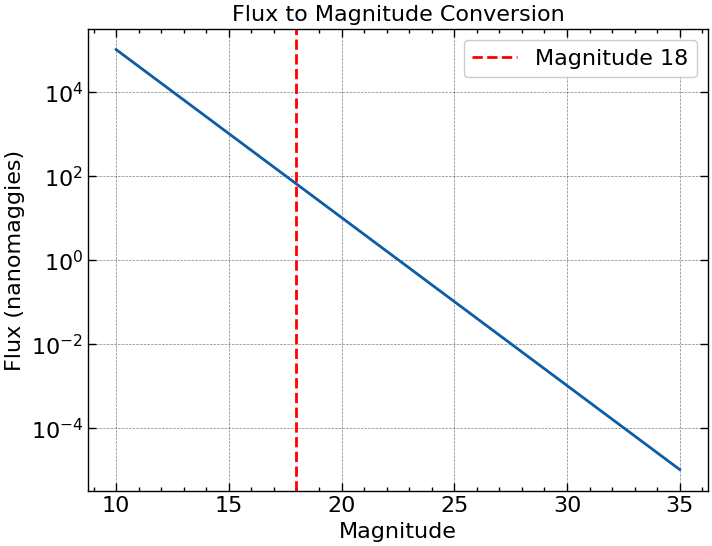

In [35]:
flux_true = np.logspace(-5,5,16000)
mag_true = -2.5 * np.log10(flux_true) + 22.5
plt.plot(mag_true,flux_true)
plt.xlabel('Magnitude')
plt.ylabel('Flux (nanomaggies)')
plt.title('Flux to Magnitude Conversion')
plt.axvline(18, color='red', linestyle='--', label='Magnitude 18')
plt.yscale('log')
plt.legend()


In [66]:
splines['north']['G'](1)

array(0.05356266)

In [ ]:
import pickle

for spline in splines:
    for band in splines[spline]:
        with open(f'/user/animesh.sah/DESI_PECVEL/flux_error_stats_DR9/spline_{spline}_{band}.pkl', 'wb') as f:
            pickle.dump(splines[spline][band], f)
        
        # Load the splines
        loaded_splines = {}
        for region in ['north', 'south']:
            loaded_splines[region] = {}
            for band in ['G', 'R', 'Z']:
                with open(f'/user/animesh.sah/DESI_PECVEL/flux_error_stats_DR9/spline_{region}_{band}.pkl', 'rb') as f:
                    loaded_splines[region][band] = pickle.load(f)

Text(0.5, 0, 'True Flux (nanomaggies)')

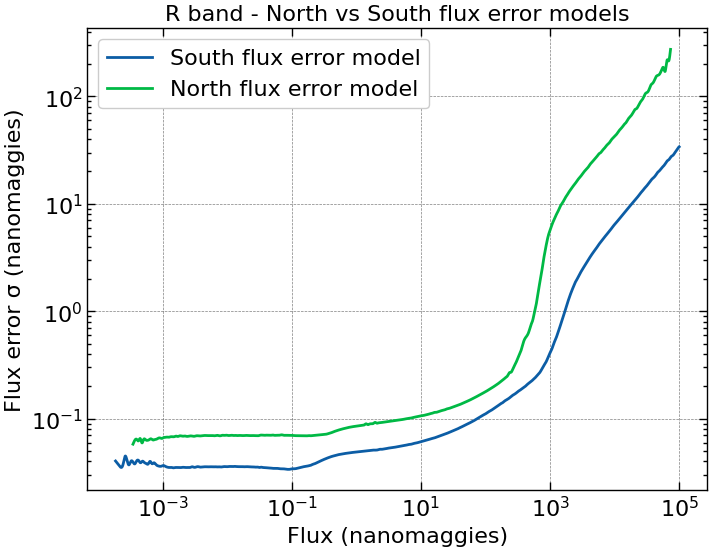

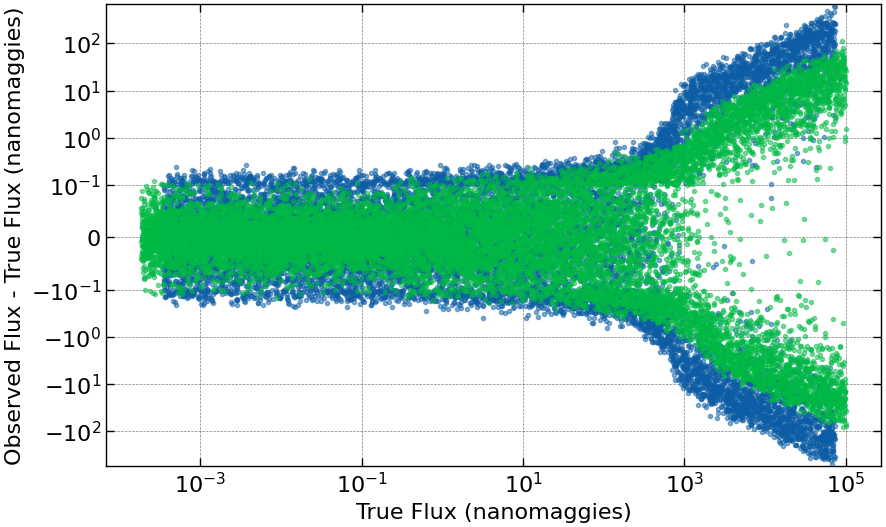

In [39]:
#flux_true = np.logspace(-3,4,16000)

plt.loglog(flux_true, splines['south']['R'](flux_true),label='South flux error model')
plt.loglog(flux_true, splines['north']['R'](flux_true),label='North flux error model')
plt.xlabel('Flux (nanomaggies)')
plt.ylabel('Flux error σ (nanomaggies)')
plt.title('R band - North vs South flux error models')
plt.legend()    



flx_observed_north = flux_true + np.random.normal(0, splines['north']['R'](flux_true))
flx_observed_south = flux_true + np.random.normal(0, splines['south']['R'](flux_true))
plt.figure(figsize=(10,6))
plt.plot(flux_true, flx_observed_north - flux_true, '.', alpha=0.5, label='North observed')
plt.plot(flux_true, flx_observed_south - flux_true, '.', alpha=0.5, label='South observed')
plt.xscale('log')
plt.yscale('symlog', linthresh=0.1)
plt.ylabel('Observed Flux - True Flux (nanomaggies)')
plt.xlabel('True Flux (nanomaggies)')   



In [47]:
kde = gaussian_kde(table['FLUX_R'][r_mask & (table['FLUX_R'] < np.percentile(table['FLUX_R'][r_mask],98))],bw_method=0.1)
samples = kde.resample(500).flatten()
samples = np.clip(samples, 0, None)
y_samples=kde.evaluate(samples)
samples_sorted=np.sort(samples)
arg=np.argsort(samples)
y_samples_sorted= y_samples[arg]

(array([1.80630240e-01, 9.59146382e-02, 2.92847625e-02, 1.18094256e-02,
        7.04303518e-03, 5.01268780e-03, 3.90434944e-03, 2.98983643e-03,
        2.56684740e-03, 2.03677253e-03, 1.89970266e-03, 1.56559487e-03,
        1.41888728e-03, 1.28502999e-03, 1.12011780e-03, 9.80906223e-04,
        9.73410215e-04, 7.97789450e-04, 8.03143741e-04, 7.15333359e-04,
        7.02483059e-04, 6.35018985e-04, 5.78263494e-04, 5.77192635e-04,
        5.57917186e-04, 4.97949120e-04, 4.43335345e-04, 4.75461095e-04,
        4.47618779e-04, 3.70516979e-04, 4.18705604e-04, 3.60879254e-04,
        3.36249513e-04, 3.44816380e-04, 3.19115780e-04, 3.15903205e-04,
        3.26611788e-04, 3.15903205e-04, 3.23399213e-04, 2.98769472e-04,
        2.42013981e-04, 2.71998014e-04, 2.70927155e-04, 2.40943122e-04,
        2.57005997e-04, 2.37730547e-04, 2.25951106e-04, 2.05604798e-04,
        1.69195615e-04, 2.03463081e-04, 1.89541923e-04, 1.67053898e-04,
        1.94896215e-04, 1.95967073e-04, 1.83116773e-04, 1.574161

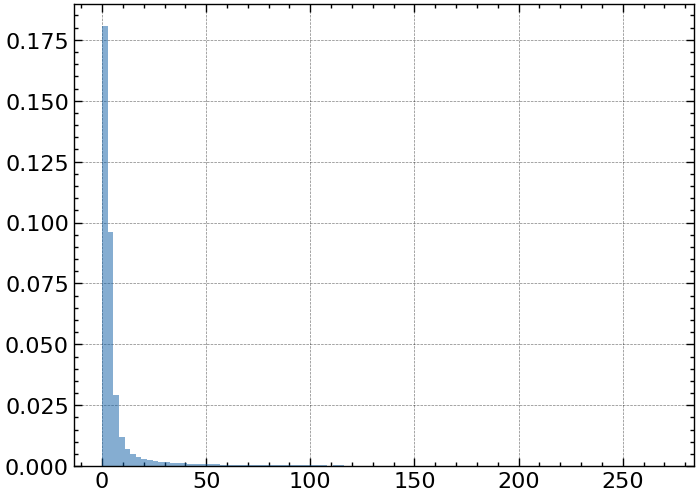

In [48]:
samples = kde.resample(500000).flatten()
plt.hist(samples[samples>1e-5], bins=100, density=True, alpha=0.5, label='KDE Samples')
#plt.hist(table['FLUX_R'][r_mask & (table['FLUX_R'] < np.percentile(table['FLUX_R'][r_mask],98))], bins=100, density=True, alpha=0.5, label='R band data',edgecolor='black')

In [ ]:
plt.plot(

In [ ]:
len(valid_mask)

16000

In [49]:
from joblib import Parallel, delayed

def run_simulation(iteration, kde, splines):
    """Single iteration of the simulation"""
    flux_true = kde.resample(50000).flatten()
    flx_observed_north = flux_true + np.random.normal(0, splines['north']['R'](flux_true))
    flx_observed_south = flux_true + np.random.normal(0, splines['south']['R'](flux_true))
    mag_observed_north = -2.5 * np.log10(flx_observed_north) + 22.5
    mag_observed_south = -2.5 * np.log10(flx_observed_south) + 22.5
    valid_mask_north = np.isfinite(mag_observed_north)
    valid_mask_south = np.isfinite(mag_observed_south)
    valid_mask = valid_mask_north & valid_mask_south
    mag_true = -2.5 * np.log10(flux_true) + 22.5
    mag_observed_north = mag_observed_north[valid_mask]
    mag_observed_south = mag_observed_south[valid_mask]
    mag_true = mag_true[valid_mask]
    cut = 18
    
    result = np.array([
        np.sum((mag_observed_north < cut) & (mag_true > cut)) / len(mag_true), 
        np.sum((mag_observed_south < cut) & (mag_true > cut)) / len(mag_true)
    ])
    return result

# Run in parallel
results = Parallel(n_jobs=-1, verbose=10)(
    delayed(run_simulation)(i, kde, splines) 
    for i in range(10000)
)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
/tmp/ipykernel_1471796/2583406891.py:8: RuntimeWarning: invalid value encountered in log10
/tmp/ipykernel_1471796/2583406891.py:9: RuntimeWarning: invalid value encountered in log10
/tmp/ipykernel_1471796/2583406891.py:13: RuntimeWarning: invalid value encountered in log10
/tmp/ipykernel_1471796/2583406891.py:8: RuntimeWarning: invalid value encountered in log10
/tmp/ipykernel_1471796/2583406891.py:9: RuntimeWarning: invalid value encountered in log10
/tmp/ipykernel_1471796/2583406891.py:13: RuntimeWarning: invalid value encountered in log10
/tmp/ipykernel_1471796/2583406891.py:8: RuntimeWarning: invalid value encountered in log10
/tmp/ipykernel_1471796/2583406891.py:8: RuntimeWarning: invalid value encountered in log10
/tmp/ipykernel_1471796/2583406891.py:9: RuntimeWarning: invalid value encountered in log10
/tmp/ipykernel_1471796/2583406891.py:9: RuntimeWarning: invalid value encountered in log10
/tmp/ipyker

In [ ]:
np.array(results)[:,1]

array([0.00000000e+00, 2.92226768e-05, 2.91825955e-05, ...,
       2.90841404e-05, 0.00000000e+00, 5.83839327e-05])

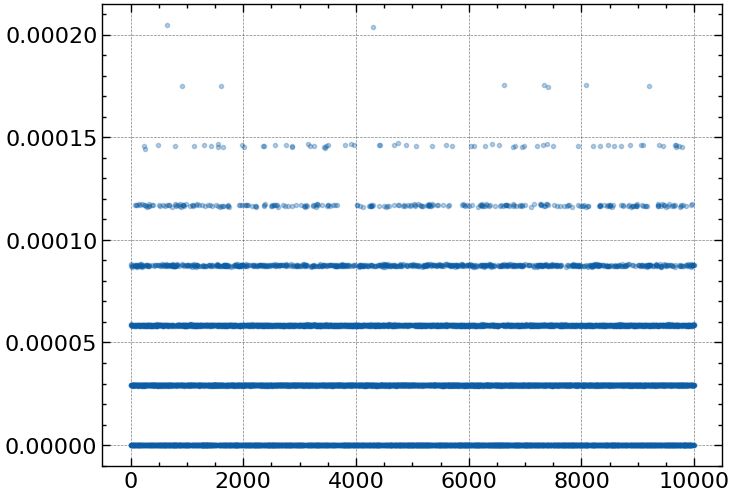

In [50]:
plt.plot( np.array(results)[:,0], '.', alpha=0.3)

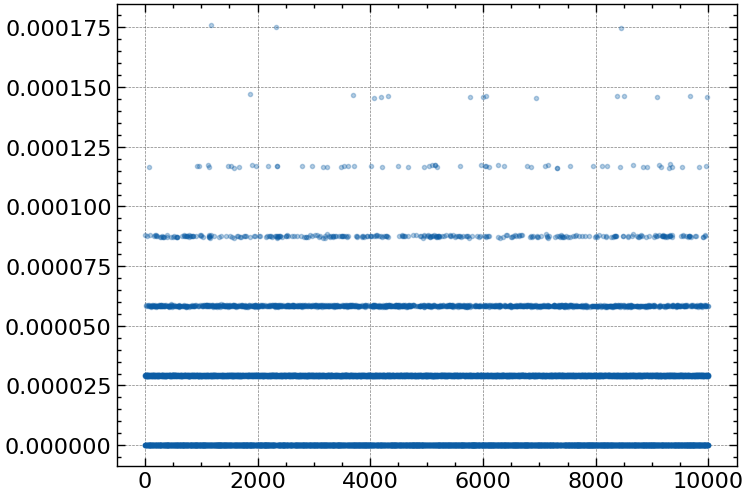

In [51]:
plt.plot( np.array(results)[:,1], '.', alpha=0.3)

In [58]:
np.median(np.array(results)[:,0])*500000

14.601098002569794

In [59]:
np.median(np.array(results)[:,1])*500000

14.5184238799036

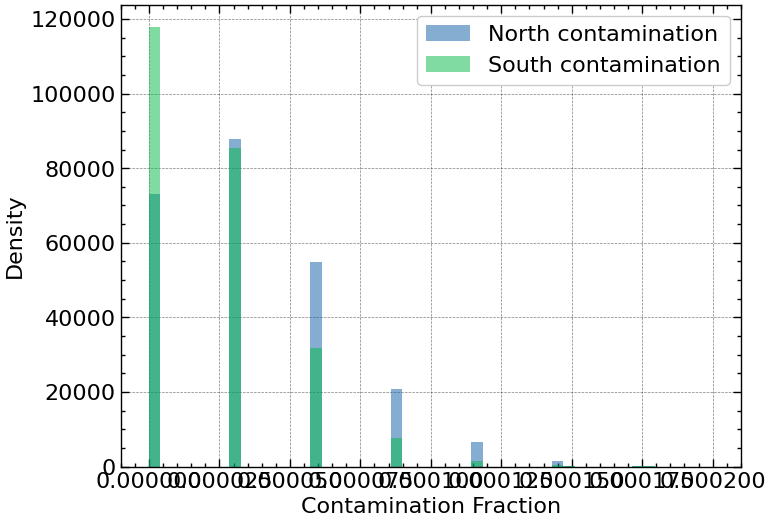

In [52]:
bins = np.linspace(0, 0.0002, 50)
plt.hist(np.array(results)[:,0], bins=bins, alpha=0.5, label='North contamination', density=True)
plt.hist(np.array(results)[:,1], bins=bins, alpha=0.5, label='South contamination', density=True)
plt.xlabel('Contamination Fraction')
plt.ylabel('Density')
plt.legend()

In [ ]:
100*len(observed_true)/ len(mag_true), 100*len(observed_north)/ len(mag_observed_north), 100*len(observed_south)/ len(mag_observed_south)

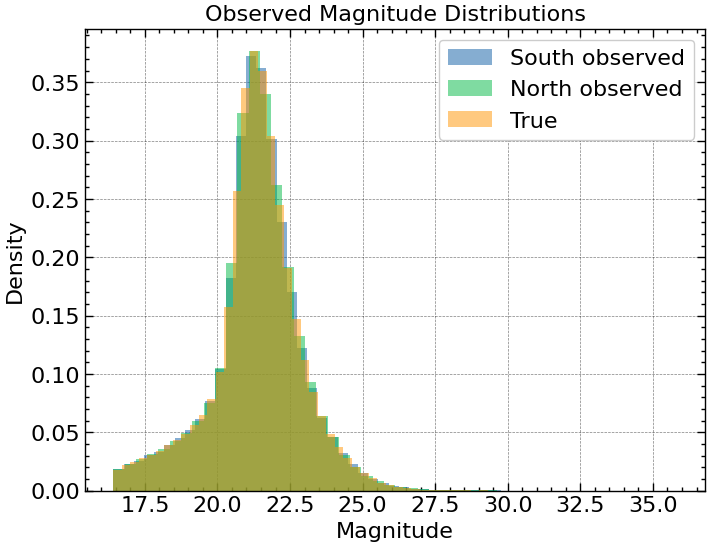

In [ ]:
plt.hist(mag_observed_south,bins=50, alpha=0.5, label='South observed', density=True)
plt.hist(mag_observed_north,bins=50, alpha=0.5, label='North observed', density=True)
plt.xlabel('Magnitude')
plt.ylabel('Density')
plt.title('Observed Magnitude Distributions')
plt.hist(mag_true,bins=50, alpha=0.5, label='True', density=True)
plt.legend()

In [ ]:
hist_south,_ = np.histogram(mag_observed_south, bins=bins, density=False)
hist_north,_ = np.histogram(mag_observed_north, bins=bins, density=False)
hist_true,_ = np.histogram(mag_true, bins=bins, density=False)
eps = 1e-10
P = (hist_true+eps)/np.sum(hist_true+eps)
Q = (hist_north+eps)/np.sum(hist_north+eps)
kl_divergence = entropy(P, Q)
print(f'KL Divergence between high noise and downgraded noise distributions: {kl_divergence:8f}')

KL Divergence between high noise and downgraded noise distributions: 0.000000


(3.9844943577339795, 3.98683130457136, 3.9830337659606165)

In [ ]:
flux_bins_south_quantile_r = np.load('/user/animesh.sah/DESI_PECVEL/flux_bins_DR9/50001_bins_FLUX_R_south_quantile.npy')
flux_bins_south_linear_r = np.load('/user/animesh.sah/DESI_PECVEL/flux_bins_DR9/50001_bins_FLUX_R_south_linear.npy')
flux_bins_south_log_r = np.load('/user/animesh.sah/DESI_PECVEL/flux_bins_DR9/50001_bins_FLUX_R_south_log.npy')

In [ ]:
flux_bins_south_log_r

array([1.00000000e-06, 1.00070114e-06, 1.00140276e-06, ...,
       1.65586108e+09, 1.65702206e+09, 1.65818386e+09])

In [ ]:
flux_bins_south_linear_r

array([1.00000000e-06, 1.38118649e+03, 2.76237298e+03, ...,
       6.90565620e+07, 6.90579432e+07, 6.90593244e+07])

In [ ]:
flux_bins_south_quantile_r

array([1.00000000e-06, 2.12120773e-04, 4.25767514e-04, ...,
       1.09749741e+05, 1.74540888e+05, 9.95095552e+07])

In [ ]:
flux = np.random.pareto(2,10000)



In [ ]:
log_bins = np.logspace(np.log10(np.min(flux)), np.log10(np.max(flux)),10 + 1)


In [ ]:
log_bins

array([1.44743099e-05, 6.81345719e-05, 3.20728237e-04, 1.50975634e-03,
       7.10683981e-03, 3.34538566e-02, 1.57476537e-01, 7.41285528e-01,
       3.48943559e+00, 1.64257365e+01, 7.73204755e+01])

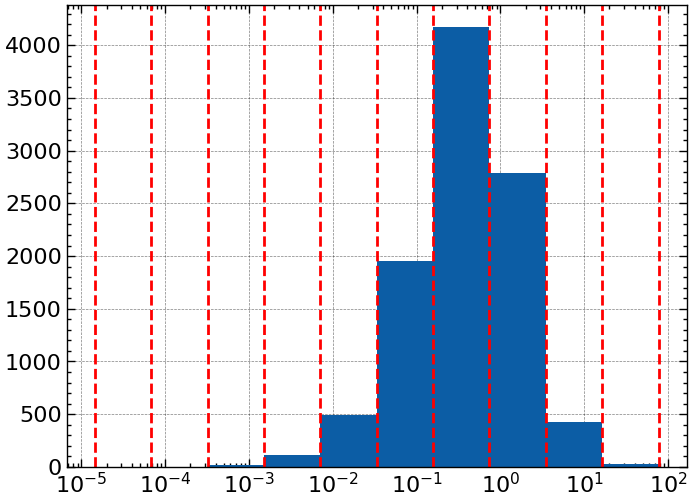

In [ ]:
plt.hist(flux,bins = log_bins)
for bins in log_bins:
    plt.axvline(bins, color='r', linestyle='--')
plt.xscale('log')

In [23]:
file_mag_north =  Table.read('/user/animesh.sah/DESI_PECVEL/flux_error_stats_DR9/mag_error_stats_north_mag.fits')
file_mag_south =  Table.read('/user/animesh.sah/DESI_PECVEL/flux_error_stats_DR9/mag_error_stats_south_mag.fits')

In [39]:
np.where(np.isfinite(file_mag_south['sigma_median_G']))

(array([ 31,  34,  35,  36,  38,  39,  40,  41,  42,  43,  44,  45,  46,
         47,  48,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59,
         60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,
         73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,
         86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,
         99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
        112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124,
        125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137,
        138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150,
        151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163,
        164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176,
        177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189,
        190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202,
        203, 204, 205, 206, 207, 208, 209, 210, 211

In [25]:
bins = np.linspace(10,32,500)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

In [ ]:
north_stats

band,flux_bin_center,sigma_median,sigma_p16,sigma_p84
bytes2,float64,float32,float64,float64
G,0.0001497044443368572,0.03947164,0.03298201397061348,0.047567914426326754
G,0.00017790389051641347,0.03932705,0.03288510143756867,0.04778795838356018
G,0.00021141519479314373,0.03941749,0.033266938477754596,0.047612781077623366
G,0.0002512389383935323,0.03954166,0.03329290673136711,0.04781772375106812
G,0.00029856417948988484,0.0396934,0.03321117147803307,0.04779002606868744
G,0.0003548039561241951,0.039566435,0.033164281994104386,0.04776782736182212
G,0.00042163747672766157,0.03948696,0.03313090652227402,0.04767133668065071
G,0.0005010602579612729,0.039498802,0.03310003399848938,0.04766034081578255
G,0.0005954437068941566,0.039483476,0.033135723024606704,0.04771812662482262


In [21]:
north_stats = Table.read('../flux_error_stats_north_test.fits')
south_stats = Table.read('../flux_error_stats_south.fits')
flux= north_stats['flux_bin_center']
sigma =    north_stats['sigma_median']

mag = -2.5 * np.log10(flux) + 22.5
mag_err = 2.5 / np.log(10) * (sigma / flux)

In [36]:
file_mag_north

NameError: name 'file_mag_north' is not defined

/user/animesh.sah/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)
/tmp/ipykernel_2203152/4155901252.py:56: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0,0.1)


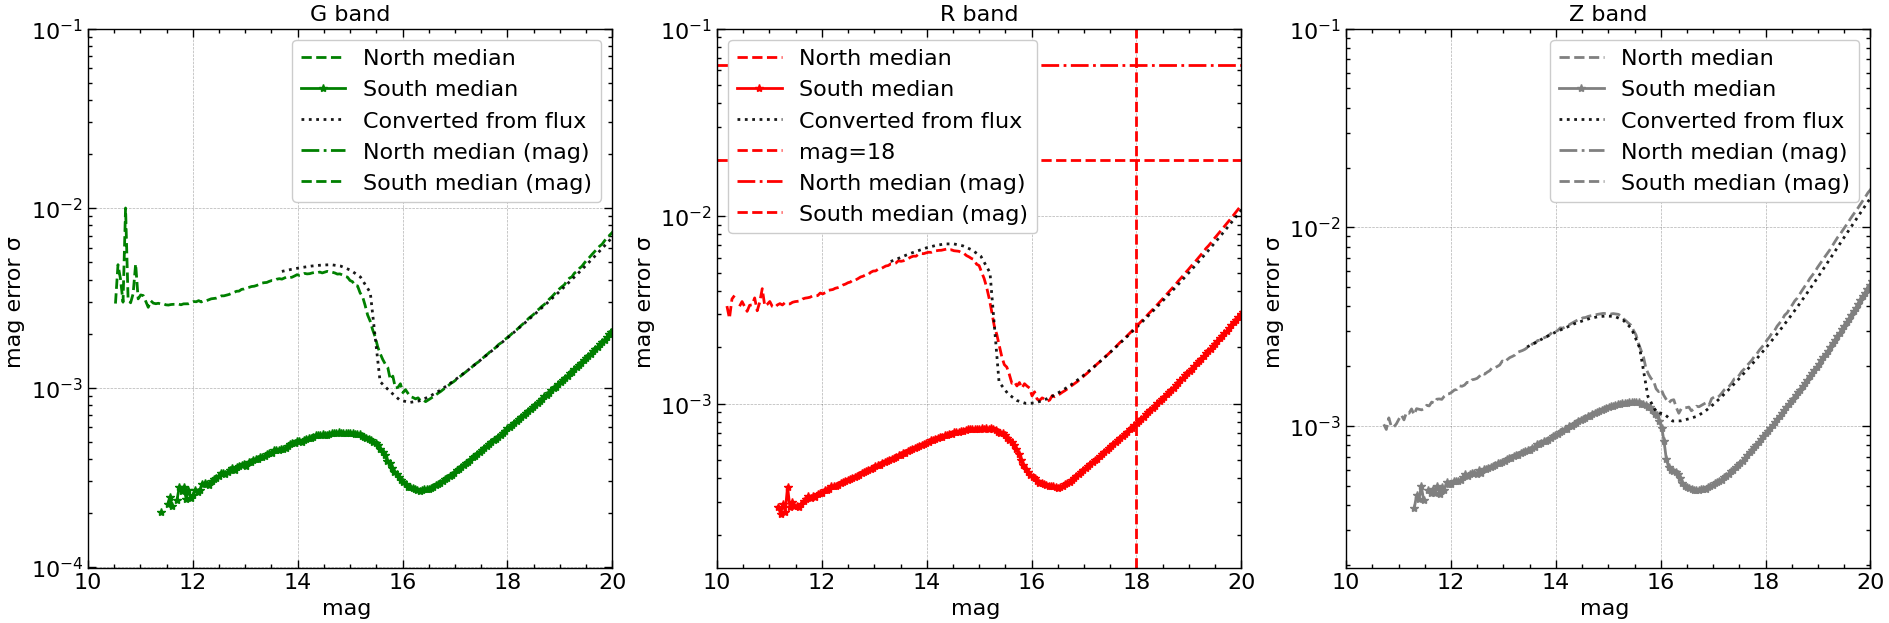

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(23, 7))
colors = {'G': 'green', 'R': 'red', 'Z': 'gray'}
for idx, band in enumerate(['G', 'R', 'Z']):
    flux= north_stats['flux_bin_center'][north_stats['band'] == band]
    sigma =    north_stats['sigma_median'][north_stats['band'] == band]
    mag = -2.5 * np.log10(flux) + 22.5
    mag_err = 2.5 / np.log(10) * (sigma / flux)
    ax = axes[idx]    
    ax.plot(
        file_mag_north['flux_bin_center'],
        file_mag_north[f'sigma_median_{band}'],'--',
        lw=2,
        label='North median',
        
        color=colors[band]
    )
    ax.plot(
        bin_centers,
        file_mag_south[f'sigma_median_{band}'],'*-',
        lw=2,
        label='South median',
        color=colors[band]
    )
    ax.plot(mag, mag_err, ':', alpha=0.9, label='Converted from flux', color='k')
    if band == 'R':
        ax.axvline(18, color='r', linestyle='--', label='mag=18')
    ax.axhline(np.median(file_mag_north[f'sigma_median_{band}']), color=colors[band], linestyle='-.', label='North median (mag)')
    ax.axhline(np.median(file_mag_south[f'sigma_median_{band}']), color=colors[band], linestyle='--', label='South median (mag)')
    # ax.plot(
    #     south_stats[f'bin_center_FLUX_{band}'],
    #     south_stats[f'sigma_median_FLUX_{band}'],'*-',
    #     lw=2,
    #     label='South median',
    #     color=colors[band]
    # )
    # ax.fill_between(
    #     south_stats[f'bin_center_FLUX_{band}'],
    #     south_stats[f'sigma_p16_FLUX_{band}'],
    #     south_stats[f'sigma_p84_FLUX_{band}'],
    #     alpha=0.3,
    #     label='16–84%',
    #     color=colors[band]
    # )
    # ax.fill_between(
    #     north_stats[f'bin_center_FLUX_{band}'],
    #     north_stats[f'sigma_p16_FLUX_{band}'],
    #     north_stats[f'sigma_p84_FLUX_{band}'],
    #     alpha=0.3,
        
    #     color=colors[band]
    # )
    
    #ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(10,20)
    ax.set_ylim(0,0.1)
    ax.set_xlabel('mag ')
    ax.set_ylabel('mag error σ ')
    ax.set_title(f'{band} band')
    ax.legend()
    ax.grid(alpha=0.3)

In [74]:
np.median(file_mag_north[f'sigma_median_R'])

0.06395032458007335

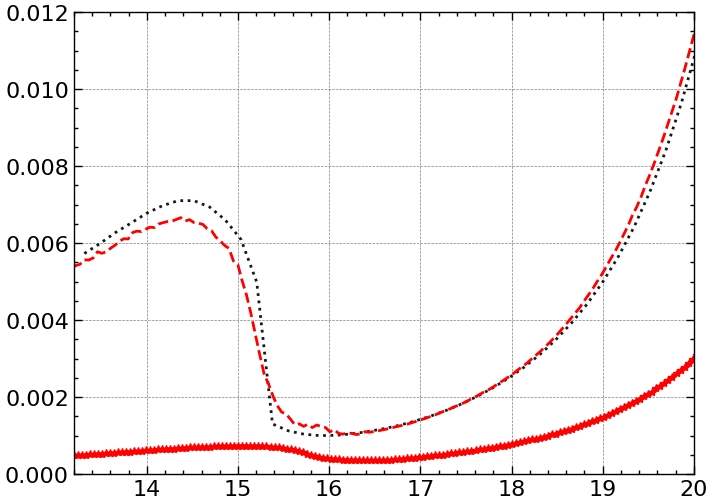

In [71]:
flux= north_stats['flux_bin_center'][north_stats['band'] == 'R']
sigma =    north_stats['sigma_median'][north_stats['band'] == 'R']

mag = -2.5 * np.log10(flux) + 22.5
mag_err = 2.5 / np.log(10) * (sigma / flux)
plt.plot(mag, mag_err, ':', alpha=0.9, label='Converted from flux', color='k')
plt.xlim(13.2,20)
plt.ylim(0.0,0.012)

plt.plot(
        file_mag_north['flux_bin_center'],
        file_mag_north[f'sigma_median_R'],'--',
        lw=2,
        label='North median',
        
        color=colors['R']
    )
plt.plot(
        bin_centers,
        file_mag_south[f'sigma_median_R'],'*-',
        lw=2,
        label='South median',
        color=colors['R']
    )

In [67]:
bin_centers[np.isclose(bin_centers, 18, atol=0.02)] 

array([18.00200401])

In [68]:
file_mag_north[f'sigma_median_R'][np.isclose(bin_centers, 18, atol=0.02)] 

0.0012288257826537806


In [63]:
file_mag_north['flux_bin_center'][np.isclose(file_mag_north['flux_bin_center'],18, atol=0.02)]

17.97995991983968


In [64]:
file_mag_north[f'sigma_median_R'][np.isclose(file_mag_north['flux_bin_center'],18, atol=0.02)]

0.002546939372663356


In [69]:
np.random.normal(np.sqrt(0.0025**2 - 0.001228**2))

-0.08399010313196877

In [70]:
np.sqrt(0.0025**2 - 0.001228**2)

0.002177617046222774